In [1]:
USE_CUDA = True

# Dependencies

## Code

In [ ]:
import time
import queue
import threading
import warnings
import multiprocessing
from functools import partial
from typing import Any, Callable, Iterator, Literal, cast

## Status

In [3]:
def print_status(message: str) -> None:
    print(f"\r{message:<80}", end="", flush=True)


def end_status(message: str = "") -> None:
    print(f"\r{message:<80}", flush=True)

In [4]:
def format_duration(seconds: float) -> str:
    minutes, remaining_seconds = divmod(int(seconds), 60)
    hours, remaining_minutes = divmod(minutes, 60)
    return f"{hours:02d}:{remaining_minutes:02d}:{remaining_seconds:02d}"

In [5]:
def print_progress(
    current: int,
    total: int,
    prefix: str = "",
    width: int = 30,
    started: float | None = None,
    suffix: str = "",
) -> None:
    fraction = current / total if total else 0
    filled = int(width * fraction)
    bar = "█" * filled + "-" * (width - filled)
    message = f"{prefix} |{bar}| {current}/{total} ({fraction:.0%})"
    if started is not None:
        elapsed = time.time() - started
        message += f" | {format_duration(elapsed)} elapsed"
        if 0 < current < total:
            message += f", ~{format_duration(elapsed / current * (total - current))} left"
    if suffix:
        message += f" | {suffix}"
    print_status(message)

In [6]:
class GridSearchProgress:
    def __init__(self, total: int, prefix: str, refresh_seconds: float = 10) -> None:
        self.total = total
        self.prefix = prefix
        self.refresh_seconds = refresh_seconds
        self.fitted = 0
        self.scored = 0
        self.failed = 0
        self.started = time.time()
        # with n_jobs != 1 the fits run in worker processes, which can only reach this process through a manager queue
        self.manager = multiprocessing.get_context("spawn").Manager()
        self.events = self.manager.Queue()
        self.listener = threading.Thread(target=self.listen, daemon=True)
        self.listener.start()

    def show(self) -> None:
        suffix = f"{self.fitted} fitted, {self.failed} failed"
        print_progress(self.scored + self.failed, self.total, self.prefix, started=self.started, suffix=suffix)

    def listen(self) -> None:
        while True:
            self.show()
            try:
                event = self.events.get(timeout=self.refresh_seconds)
            except queue.Empty:
                continue
            if event is None:
                return
            if event == "fitted":
                self.fitted += 1
            elif event == "scored":
                self.scored += 1
            else:
                self.failed += 1

    def close(self) -> None:
        self.events.put(None)
        self.listener.join()
        self.manager.shutdown()

## OS, Systems, and File's Manager

In [7]:
import os
import sys
import gc
import shutil
import hashlib
import joblib
import json

### Configurations

In [8]:
ROW_INDEX_COLUMN = "row_index"

### Loading Data

In [9]:
def get_file_paths_in_folder(folder_path: str, file_extension: str) -> list[str]:
    file_paths = []
    for file_name in os.listdir(folder_path):
        if file_name.endswith(f".{file_extension}"):
            file_paths.append(os.path.join(folder_path, file_name))
    return sorted(file_paths)

### Dump and Load

In [10]:
def load(object_path: str) -> Any:
    return joblib.load(object_path)

In [11]:
def dump(obj: Any, dump_path: str) -> None:
    joblib.dump(obj, dump_path)

### File's Path

In [12]:
# cached path
PATH_FOLDER_CACHE = "cache"
PATH_FOLDER_TRAINED_MODEL = "trained-models"
PATH_FOLDER_GRID_SEARCH = "grid-search"
PATH_FOLDER_EVALUATION = "evaluation"
PATH_FOLDER_NOISE_EVALUATION = "noise-evaluation"
PATH_FOLDER_PREDICTIONS = "predictions"

In [13]:
# class label's
PATH_JSON_ORIGINAL_CLASSES_LIST = os.path.join(PATH_FOLDER_CACHE, "original-classes.json")
PATH_JSON_MINIMIZED_CLASSES_LIST = os.path.join(PATH_FOLDER_CACHE, "minimized-classes.json")
PATH_JSON_CURRENTLY_USED_CLASSES_LIST = PATH_JSON_ORIGINAL_CLASSES_LIST

In [14]:
# transformers
PATH_LABEL_ENCODER_TRANSFORMER = os.path.join(PATH_FOLDER_CACHE, "label-encoder-transformer.pkl")
PATH_STANDARD_SCALER_TRANSFORMER = os.path.join(PATH_FOLDER_CACHE, "standard-scaler-transformer.pkl")
PATH_PCA_TRANSFORMER = os.path.join(PATH_FOLDER_CACHE, "pca.npz")

In [15]:
# data pipeline path
PATH_FOLDER_ORIGINAL_DATASET = "cse-cic-ids2018"
PATH_FOLDER_DATA_PIPELINE = "data-pipeline"
PATH_FOLDER_TRAINED_MODEL_WOUT_SMOTE = os.path.join(PATH_FOLDER_TRAINED_MODEL, "wout-smote")
PATH_FOLDER_TRAINED_MODEL_WITH_SMOTE = os.path.join(PATH_FOLDER_TRAINED_MODEL, "with-smote")
PATH_FOLDER_GRID_SEARCH_WOUT_SMOTE = os.path.join(PATH_FOLDER_GRID_SEARCH, "wout-smote")
PATH_FOLDER_GRID_SEARCH_WITH_SMOTE = os.path.join(PATH_FOLDER_GRID_SEARCH, "with-smote")
PATH_FOLDER_EVALUATION_MATRICES = os.path.join(PATH_FOLDER_EVALUATION, "matrices")
PATH_FOLDER_PARQUET_DATASET = os.path.join(PATH_FOLDER_DATA_PIPELINE, "01-raw-parquet")
PATH_FOLDER_CLEANED_DATASET = os.path.join(PATH_FOLDER_DATA_PIPELINE, "02-cleaned-parquet")
PATH_FOLDER_DEDUPLICATED_DATASET = os.path.join(PATH_FOLDER_DATA_PIPELINE, "03-deduplicated-parquet")
PATH_FOLDER_SPLITTED_DATASET = os.path.join(PATH_FOLDER_DATA_PIPELINE, "04-splitted-parquet")
PATH_FOLDER_SPLITTED_DATASET_TRAIN = os.path.join(PATH_FOLDER_SPLITTED_DATASET, "train")
PATH_FOLDER_SPLITTED_DATASET_TEST = os.path.join(PATH_FOLDER_SPLITTED_DATASET, "test")
PATH_FOLDER_NOISY_DATASET = os.path.join(PATH_FOLDER_DATA_PIPELINE, "06-noisy-parquet")
PATH_FOLDER_NOISY_DATASET_TEST = os.path.join(PATH_FOLDER_NOISY_DATASET, "test")

### File's Name

In [16]:
FEATURES_FILE_NAME = "features.parquet"
LABELS_FILE_NAME = "labels.parquet"
ENCODED_LABELS_FILE_NAME = "encoded-labels.parquet"

# noisy datasets
NOISE_CHECK_FILE_NAME = "noise-check.csv"

# predictions
PREDICTIONS_FILE_NAME = "predictions.parquet"

# evaluation results
OUTCOME_COUNTS_FILE_NAME = "outcome-counts.parquet"
DISPLACEMENT_BINS_FILE_NAME = "displacement-bins.csv"
METRICS_FILE_NAME = "metrics.csv"
DEGRADATION_FILE_NAME = "degradation.csv"
ROBUSTNESS_RANKING_FILE_NAME = "robustness-ranking.csv"
MIXTURE_CHECK_FILE_NAME = "mixture-check.csv"
SMOTE_EFFECT_FILE_NAME = "smote-effect.csv"
CLASS_METRICS_FILE_NAME = "class-metrics.csv"
ERROR_COMPOSITION_FILE_NAME = "error-composition.csv"
PREDICTION_SUMMARIES_FILE_NAME = "prediction-summaries.csv"
KEY_FINDINGS_FILE_NAME = "key-findings.csv"
MODEL_COMPARISON_PLOT_FILE_NAME = "model-comparison.png"
ERROR_COMPOSITION_PLOT_FILE_NAME = "error-composition.png"
FLIP_RATE_PLOT_FILE_NAME = "flip-rate-against-displacement.png"
CONFUSION_MATRIX_PLOT_FILE_NAME = "confusion-matrix.png"
PREDICTION_TRANSITIONS_PLOT_FILE_NAME = "prediction-transitions.png"

## Data Processing

In [17]:
import re
import numpy as np
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq

In [18]:
if USE_CUDA:
    cuda_root = os.path.join(sys.prefix, "targets", "x86_64-linux")
    if os.path.isdir(os.path.join(cuda_root, "include")):
        os.environ.setdefault("CUDA_PATH", cuda_root)
    os.environ.setdefault("CUDA_CACHE_MAXSIZE", str(4 * 1024**3))

### Configurations

In [20]:
NUMERIC_DATA_TYPE = "float32"
LABEL_COLUMN = "label"
CLASS_COLUMN = "class"
ROW_COUNT_COLUMN = "rows"
BATCH_SIZE = 500_000
RANDOM_STATE = 42

### Batch Processing

In [21]:
def count_rows(dataset: pl.LazyFrame) -> int:
    return dataset.select(pl.len()).collect().item()

In [22]:
def read_in_batches(
    dataset: pl.LazyFrame,
    prefix: str = "Reading batches",
    batch_size: int = BATCH_SIZE,
) -> Iterator[tuple[int, pl.DataFrame]]:
    row_offsets = range(0, count_rows(dataset), batch_size)
    started = time.time()
    print_progress(0, len(row_offsets), prefix, started=started)
    for batch_index, row_offset in enumerate(row_offsets, start=1):
        yield row_offset, dataset.slice(row_offset, batch_size).collect()
        print_progress(batch_index, len(row_offsets), prefix, started=started)

In [ ]:
def load_features(
    features: pl.LazyFrame,
    prefix: str = "Loading features",
    batch_size: int = BATCH_SIZE,
    numeric_data_type: str = NUMERIC_DATA_TYPE,
) -> pd.DataFrame:
    columns = features.collect_schema().names()
    values = np.empty((count_rows(features), len(columns)), dtype=numeric_data_type)
    for row_offset, batch in read_in_batches(features, prefix, batch_size):
        values[row_offset:row_offset + len(batch)] = batch.to_numpy()
    return pd.DataFrame(values, columns=columns)

### Load All Files

In [23]:
def load_all_files(folder_path: str, row_index_column: str = ROW_INDEX_COLUMN) -> pl.LazyFrame:
    file_paths = get_file_paths_in_folder(folder_path, "parquet")
    return pl.scan_parquet(file_paths).with_row_index(row_index_column)

### Classes List

In [24]:
def get_classes_list_from_a_folder(
    folder_path: str,
    file_extension: Literal["csv", "parquet"],
    label_column: str = LABEL_COLUMN,
) -> list[str]:
    if file_extension not in ("csv", "parquet"):
        raise ValueError("file_extension must be 'csv' or 'parquet'")

    classes = set()
    file_paths = get_file_paths_in_folder(folder_path, file_extension)
    started = time.time()
    for file_index, file_path in enumerate(file_paths, start=1):
        if file_extension == "csv":
            dataframe = pd.read_csv(
                file_path,
                usecols=lambda column: normalize_column_name(column) == label_column,
            )
            labels = dataframe.iloc[:, 0]
            labels = labels[labels != labels.name]
        else:
            labels = pd.read_parquet(file_path, columns=[label_column])[label_column]
        classes.update(labels.dropna().unique())
        print_progress(file_index, len(file_paths), "Reading classes", started=started)

    end_status(f"Found {len(classes)} classes in {len(file_paths)} files")
    return sorted(classes)

In [25]:
def create_classes_list_from_a_folder(
    folder_path: str,
    output_path: str = PATH_JSON_CURRENTLY_USED_CLASSES_LIST,
    label_column: str = LABEL_COLUMN,
) -> list[str]:
    if get_file_paths_in_folder(folder_path, "parquet"):
        file_extension = "parquet"
    elif get_file_paths_in_folder(folder_path, "csv"):
        file_extension = "csv"
    else:
        raise FileNotFoundError(f"No csv or parquet files found in {folder_path}")

    classes = get_classes_list_from_a_folder(folder_path, file_extension, label_column)

    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as file:
        json.dump(classes, file, indent=4)

    return classes

In [26]:
def load_classes_list(file_path: str = PATH_JSON_CURRENTLY_USED_CLASSES_LIST) -> list[str]:
    with open(file_path, "r", encoding="utf-8") as file:
        return json.load(file)

In [27]:
def count_classes_in_split(
    split_folder_path: str,
    labels_file_name: str = LABELS_FILE_NAME,
    label_column: str = LABEL_COLUMN,
) -> pd.Series:
    labels_file_path = os.path.join(split_folder_path, labels_file_name)
    class_counts = pl.scan_parquet(labels_file_path).group_by(label_column).len().collect()
    return class_counts.to_pandas().set_index(label_column)["len"]

### Cast to `float32`

In [28]:
def _to_float32(x:pd.DataFrame):
    return x.astype(np.float32)

### Feature Columns

In [29]:
def get_feature_columns(
    folder_path: str = PATH_FOLDER_PARQUET_DATASET,
    label_column: str = LABEL_COLUMN,
) -> list[str]:
    first_file_path = get_file_paths_in_folder(folder_path, "parquet")[0]
    feature_columns = []
    for column in pq.read_schema(first_file_path).names:
        if column != label_column:
            feature_columns.append(column)
    return feature_columns

## Parallel Processing

In [30]:
def create_tasks_list(function: Callable, per_task_arguments: list, *shared_arguments: Any) -> list:
    tasks = []
    for per_task_argument in per_task_arguments:
        task = joblib.delayed(function)(per_task_argument, *shared_arguments)
        tasks.append(task)
    return tasks

In [31]:
def run_tasks_in_parallel(tasks: list, n_jobs: int = -1, prefix: str = "Running tasks"):
    started = time.time()
    print_progress(0, len(tasks), prefix, started=started)
    results = []
    with joblib.parallel_config(backend="loky", inner_max_num_threads=1):
        for result in joblib.Parallel(n_jobs=n_jobs, return_as="generator")(tasks):
            results.append(result)
            print_progress(len(results), len(tasks), prefix, started=started)
    return results

## Segregate Data

In [32]:
def extract_column(
    dataframe: pd.DataFrame,
    source_column: str,
    target_column: str,
    regex: str,
) -> pd.DataFrame:
    dataframe = dataframe.copy()
    dataframe[target_column] = dataframe[source_column].str.extract(regex)[0]
    return dataframe

In [33]:
def group_and_sum(
    dataframe: pd.DataFrame,
    source_column: str,
    group_column: str,
    regex: str,
    value_columns: str | list[str] | None = None,
) -> pd.DataFrame:
    dataframe = extract_column(dataframe, source_column, group_column, regex)

    if value_columns is None:
        value_columns = dataframe.select_dtypes("number").columns.tolist()
    elif isinstance(value_columns, str):
        value_columns = [value_columns]

    return dataframe.groupby(group_column, as_index=False)[value_columns].sum()

## Plotting

In [34]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### Colors

In [35]:
BAR_COLOR = "#2a78d6"
GRID_COLOR = "#e1e0d9"
TEXT_COLOR = "#0b0b0b"
TEXT_ON_DARK_COLOR = "#ffffff"
EMPTY_CELL_COLOR = "#fcfcfb"
# categorical colors, given to the series in this fixed order
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SERIES_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]

SEQUENTIAL_COLORMAP = mcolors.LinearSegmentedColormap.from_list(
    "sequential_blue",
    ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"],
).with_extremes(bad=EMPTY_CELL_COLOR)

DIVERGING_COLORMAP = mcolors.LinearSegmentedColormap.from_list(
    "diverging_blue_red",
    ["#2a78d6", "#f0efec", "#e34948"],
).with_extremes(bad=EMPTY_CELL_COLOR)

FIGURE_DPI = 300  # resolution of the saved figures

### Plot Function

In [36]:
def plot_bar(
    dataframe: pd.DataFrame,
    x: str,
    y: str,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    figsize: tuple[int, int] = (10, 5),
    rotation: int = 45,
    log_scale: bool = False,
) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(dataframe[x].astype(str), dataframe[y], color=BAR_COLOR, zorder=3)
    ax.set_title(title or f"{y} per {x}")
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    if log_scale:
        ax.set_yscale("log")
    else:
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

In [37]:
def plot_heatmap(
    matrix: pd.DataFrame,
    title: str,
    colormap: mcolors.Colormap = SEQUENTIAL_COLORMAP,
    value_range: tuple[float | None, float | None] = (None, None),
    log_scale: bool = False,
    annotate: bool = False,
    annotation_format: str = ",.0f",
    xlabel: str = "",
    ylabel: str = "",
    colorbar_label: str = "",
    figsize: tuple[int, int] = (12, 10),
    font_size: int = 8,
    save_path: str | None = None,
    show: bool = True,
) -> None:
    values = matrix.to_numpy(dtype=float)
    if log_scale:
        values = np.ma.masked_less_equal(values, 0)
        normalization = mcolors.LogNorm(*value_range)
    else:
        normalization = mcolors.Normalize(*value_range)

    fig, ax = plt.subplots(figsize=figsize)
    image = ax.imshow(values, cmap=colormap, norm=normalization, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=90, fontsize=font_size)
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_yticklabels(matrix.index, fontsize=font_size)
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(colorbar_label)

    if annotate:
        for row_index in range(matrix.shape[0]):
            for column_index in range(matrix.shape[1]):
                value = values[row_index, column_index]
                if value is np.ma.masked or np.isnan(value):
                    continue
                if normalization(value) > 0.6:
                    text_color = TEXT_ON_DARK_COLOR
                else:
                    text_color = TEXT_COLOR
                ax.text(
                    column_index,
                    row_index,
                    f"{value:{annotation_format}}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=font_size,
                )

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

## Encode Classes' Label

In [38]:
from sklearn.preprocessing import LabelEncoder, FunctionTransformer

## Pipelines

In [39]:
from imblearn.pipeline import Pipeline
from sklearn.base import clone

### Splitting Datasets

In [40]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV, ParameterGrid

### Features Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

### Principal Component Analysis

In [42]:
from sklearn.decomposition import PCA

### Synthetic Minority Oversampling Technique (SMOTE)

In [43]:
from imblearn.over_sampling import SMOTE

### Models

In [44]:
from cuml import KNeighborsClassifier, SVC, LinearSVC, RandomForestClassifier, LogisticRegression
from xgboost import XGBClassifier

### Metrics

In [45]:
from sklearn.metrics import make_scorer, get_scorer, f1_score, precision_score, recall_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score, confusion_matrix

# CSV To Parquet

## Configurations

In [ ]:
CHUNK_SIZE = 100_000

COLUMNS_TO_DROP = {
    "flow id",
    "src ip",
    "source ip",
    "src port",
    "source port",
    "dst ip",
    "destination ip",
    "timestamp",
}

## Normalize Columns

In [ ]:
def normalize_column_name(column_name: Any) -> str:
    column_name = str(column_name).strip().lower()
    column_name = re.sub(r"[^0-9a-z]+", "_", column_name)
    return column_name.strip("_")

In [ ]:
def normalize_column_names(column_names: list) -> list[str]:
    normalized_column_names = []
    for column_name in column_names:
        normalized_column_names.append(normalize_column_name(column_name))
    return normalized_column_names

## Create Schema

In [ ]:
def create_schema_columns(folder_path: str, columns_to_drop: set[str] = COLUMNS_TO_DROP) -> list[str]:
    columns = set()
    for file_path in get_file_paths_in_folder(folder_path, "csv"):
        raw_columns = pd.read_csv(file_path, nrows=0).columns.tolist()
        columns.update(normalize_column_names(raw_columns))
    columns -= set(normalize_column_names(list(columns_to_drop)))
    return sorted(columns)

In [ ]:
def create_schema(folder_path: str) -> pd.DataFrame:
    columns = create_schema_columns(folder_path)

    dtypes = []
    for column in columns:
        if column == LABEL_COLUMN:
            dtypes.append("str")
        else:
            dtypes.append(NUMERIC_DATA_TYPE)

    return pd.DataFrame({"column": columns, "dtype": dtypes})

## Cast Numeric Column to `float32`

In [ ]:
def cast_numeric_columns(
    dataframe: pd.DataFrame,
    numeric_data_type: Any = NUMERIC_DATA_TYPE,
) -> pd.DataFrame:
    dataframe = dataframe.copy()

    for column in dataframe.columns:
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            dataframe[column] = dataframe[column].astype(numeric_data_type)

    return dataframe

## Apply Schema Template

In [ ]:
def apply_schema_to_dataframe(
    dataframe: pd.DataFrame,
    schema: pd.DataFrame,
    numeric_data_type: str = NUMERIC_DATA_TYPE,
) -> pd.DataFrame:
    dataframe = dataframe.rename(columns=normalize_column_name)
    dataframe = dataframe.reindex(columns=schema["column"].tolist())

    for column, dtype in zip(schema["column"], schema["dtype"]):
        if not isinstance(dtype, str) or dtype == "":
            continue

        if dtype.startswith(("int", "float")):
            numeric_values = pd.to_numeric(dataframe[column], errors="coerce")
            dataframe[column] = numeric_values.astype(numeric_data_type)
        else:
            try:
                dataframe[column] = dataframe[column].astype(dtype)
            except (ValueError, TypeError) as error:
                warnings.warn(f"Could not cast column '{column}' to {dtype}: {error}")

    return dataframe

## Remove Duplicate Header

In [ ]:
def remove_duplicate_header(dataframe: pd.DataFrame) -> pd.DataFrame:
    is_header_row = dataframe.eq(dataframe.columns.tolist(), axis=1).all(axis=1)
    return dataframe[~is_header_row].reset_index(drop=True)

## Clean A Single Chunk

In [ ]:
def clean_chunk(dataframe: pd.DataFrame, schema: pd.DataFrame) -> pd.DataFrame:
    dataframe = remove_duplicate_header(dataframe)
    dataframe = apply_schema_to_dataframe(dataframe, schema)
    return dataframe

## Write Chunk to Parquet

In [ ]:
def write_chunk_to_parquet(
    chunk: pd.DataFrame,
    chunk_index: int,
    csv_file_path: str,
    output_folder_path: str,
) -> str:
    os.makedirs(output_folder_path, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(csv_file_path))[0]
    output_path = os.path.join(output_folder_path, f"{base_name}_part{chunk_index:04d}.parquet")
    chunk.to_parquet(output_path, index=False)
    return output_path

## Convert A Single CSV

In [ ]:
def convert_csv_to_parquet(
    csv_file_path: str,
    schema: pd.DataFrame,
    output_folder_path: str = PATH_FOLDER_PARQUET_DATASET,
    chunk_size: int = CHUNK_SIZE,
) -> list[str]:
    file_name = os.path.basename(csv_file_path)
    parquet_file_paths = []

    with pd.read_csv(csv_file_path, chunksize=chunk_size, low_memory=False) as chunks:
        for chunk_index, chunk in enumerate(chunks):
            chunk_index_interface = chunk_index + 1
            print_status(f"{file_name}: writing chunk {chunk_index_interface}")
            chunk = clean_chunk(chunk, schema)
            parquet_file_path = write_chunk_to_parquet(chunk, chunk_index_interface, csv_file_path, output_folder_path)
            parquet_file_paths.append(parquet_file_path)

    end_status(f"{file_name}: {len(parquet_file_paths)} chunks written")
    return parquet_file_paths

## Convert All CSV Files to Parquet

In [ ]:
def convert_all_csv_to_parquet(
    csv_folder_path: str = PATH_FOLDER_ORIGINAL_DATASET,
    n_jobs: int = -1,
) -> None:
    csv_file_paths = get_file_paths_in_folder(csv_folder_path, "csv")
    schema = create_schema(csv_folder_path)

    tasks = create_tasks_list(convert_csv_to_parquet, csv_file_paths, schema)
    results = run_tasks_in_parallel(tasks, n_jobs, "Converting CSV files to parquet")

    parquet_file_paths = []
    for result in results:
        parquet_file_paths.extend(result)

    end_status(f"Finished converting {len(csv_file_paths)} CSV files into {len(parquet_file_paths)} parquet files")

## Do the Converting

In [ ]:
convert_all_csv_to_parquet()

# Exploratory Data Analysis (EDA)

In [67]:
FILE_COLUMN = "file"
DAY_COLUMN = "day"
FEATURE_COLUMN = "feature"
PERCENTAGE_COLUMN = "percentage"
MISSING_COUNT_COLUMN = "missing"
NAN_COUNT_COLUMN = "nan"
INFINITE_COUNT_COLUMN = "infinite"
UNIQUE_COUNT_COLUMN = "unique"
CORRELATION_COLUMN = "correlation"

DAY_REGEX = r"^(\d{4}-\d{2}-\d{2})"
CORRELATION_THRESHOLD = 0.95
EDA_N_JOBS = 8

## Count Rows Per Day

In [68]:
def count_rows_in_a_single_file(file_path: str) -> int:
    return pq.ParquetFile(file_path).metadata.num_rows

In [69]:
def count_rows_in_all_files(
    folder_path: str = PATH_FOLDER_PARQUET_DATASET,
    file_column: str = FILE_COLUMN,
    row_count_column: str = ROW_COUNT_COLUMN,
) -> pd.DataFrame:
    records = []
    for file_path in get_file_paths_in_folder(folder_path, "parquet"):
        record = {
            file_column: os.path.basename(file_path),
            row_count_column: count_rows_in_a_single_file(file_path),
        }
        records.append(record)
    return pd.DataFrame(records)

In [70]:
results = group_and_sum(count_rows_in_all_files(), FILE_COLUMN, DAY_COLUMN, DAY_REGEX, ROW_COUNT_COLUMN)
display(results)

,day,rows
0,2018-02-14,1048575
1,2018-02-15,1048575
2,2018-02-16,1048574
3,2018-02-20,7948748
4,2018-02-21,1048575
5,2018-02-22,1048575
6,2018-02-23,1048575
7,2018-02-28,613071
8,2018-03-01,331100
9,2018-03-02,1048575


### Plot Row Count Each Day

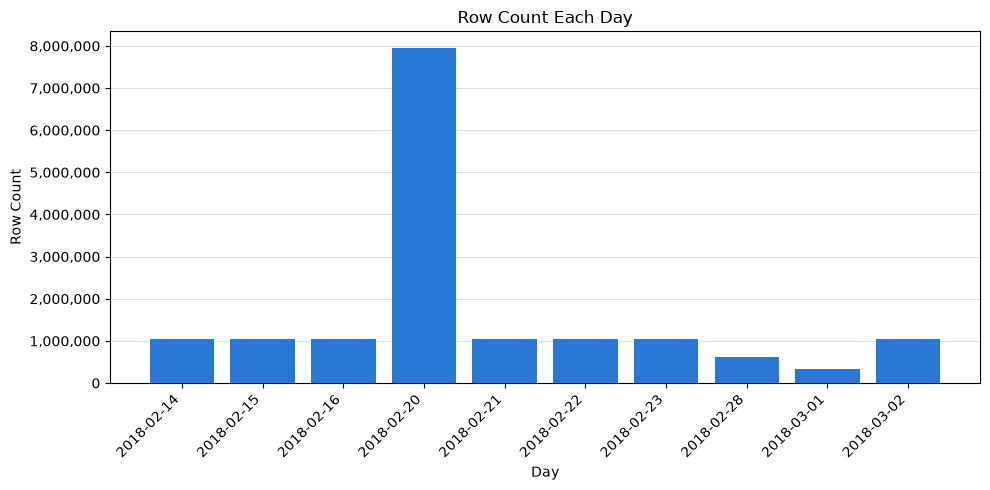

In [71]:
plot_bar(results, DAY_COLUMN, ROW_COUNT_COLUMN, "Row Count Each Day", "Day", "Row Count")
del results

## Count Class Distribution

In [72]:
results = create_classes_list_from_a_folder(PATH_FOLDER_PARQUET_DATASET)
display(results)
del results

['Benign',
 'Bot',
 'Brute Force -Web',
 'Brute Force -XSS',
 'DDOS attack-HOIC',
 'DDOS attack-LOIC-UDP',
 'DDoS attacks-LOIC-HTTP',
 'DoS attacks-GoldenEye',
 'DoS attacks-Hulk',
 'DoS attacks-SlowHTTPTest',
 'DoS attacks-Slowloris',
 'FTP-BruteForce',
 'Infilteration',
 'SQL Injection',
 'SSH-Bruteforce']

In [73]:
def count_classes_in_a_single_file(
    file_path: str,
    label_column: str = LABEL_COLUMN,
    classes_list: list[str] | None = None,
    file_column: str = FILE_COLUMN,
) -> pd.DataFrame:
    if classes_list is None:
        classes_list = load_classes_list()

    labels = pd.read_parquet(file_path, columns=[label_column])[label_column]
    counts = labels.value_counts().reindex(classes_list, fill_value=0)

    record = {file_column: os.path.basename(file_path), **counts.to_dict()}
    return pd.DataFrame([record])

In [74]:
def count_classes_in_all_files(
    folder_path: str = PATH_FOLDER_PARQUET_DATASET,
    label_column: str = LABEL_COLUMN,
    classes_list: list[str] | None = None,
    n_jobs: int = EDA_N_JOBS,
) -> pd.DataFrame:
    if classes_list is None:
        classes_list = load_classes_list()

    file_paths = get_file_paths_in_folder(folder_path, "parquet")
    tasks = create_tasks_list(count_classes_in_a_single_file, file_paths, label_column, classes_list)

    results = run_tasks_in_parallel(tasks, n_jobs, "Counting classes")
    end_status(f"Counted classes in {len(tasks)} files")

    return pd.concat(results, ignore_index=True)

In [75]:
results = group_and_sum(count_classes_in_all_files(), FILE_COLUMN, DAY_COLUMN, DAY_REGEX)
display(results)

Counted classes in 168 files                                                    


,day,Benign,Bot,Brute Force -Web,Brute Force -XSS,DDOS attack-HOIC,DDOS attack-LOIC-UDP,DDoS attacks-LOIC-HTTP,DoS attacks-GoldenEye,DoS attacks-Hulk,DoS attacks-SlowHTTPTest,DoS attacks-Slowloris,FTP-BruteForce,Infilteration,SQL Injection,SSH-Bruteforce
0,2018-02-14,667626,0,0,0,0,0,0,0,0,0,0,193360,0,0,187589
1,2018-02-15,996077,0,0,0,0,0,0,41508,0,0,10990,0,0,0,0
2,2018-02-16,446772,0,0,0,0,0,0,0,461912,139890,0,0,0,0,0
3,2018-02-20,7372557,0,0,0,0,0,576191,0,0,0,0,0,0,0,0
4,2018-02-21,360833,0,0,0,686012,1730,0,0,0,0,0,0,0,0,0
5,2018-02-22,1048213,0,249,79,0,0,0,0,0,0,0,0,0,34,0
6,2018-02-23,1048009,0,362,151,0,0,0,0,0,0,0,0,0,53,0
7,2018-02-28,544200,0,0,0,0,0,0,0,0,0,0,0,68871,0,0
8,2018-03-01,238037,0,0,0,0,0,0,0,0,0,0,0,93063,0,0
9,2018-03-02,762384,286191,0,0,0,0,0,0,0,0,0,0,0,0,0


### Plot Label Classes (Each Day)

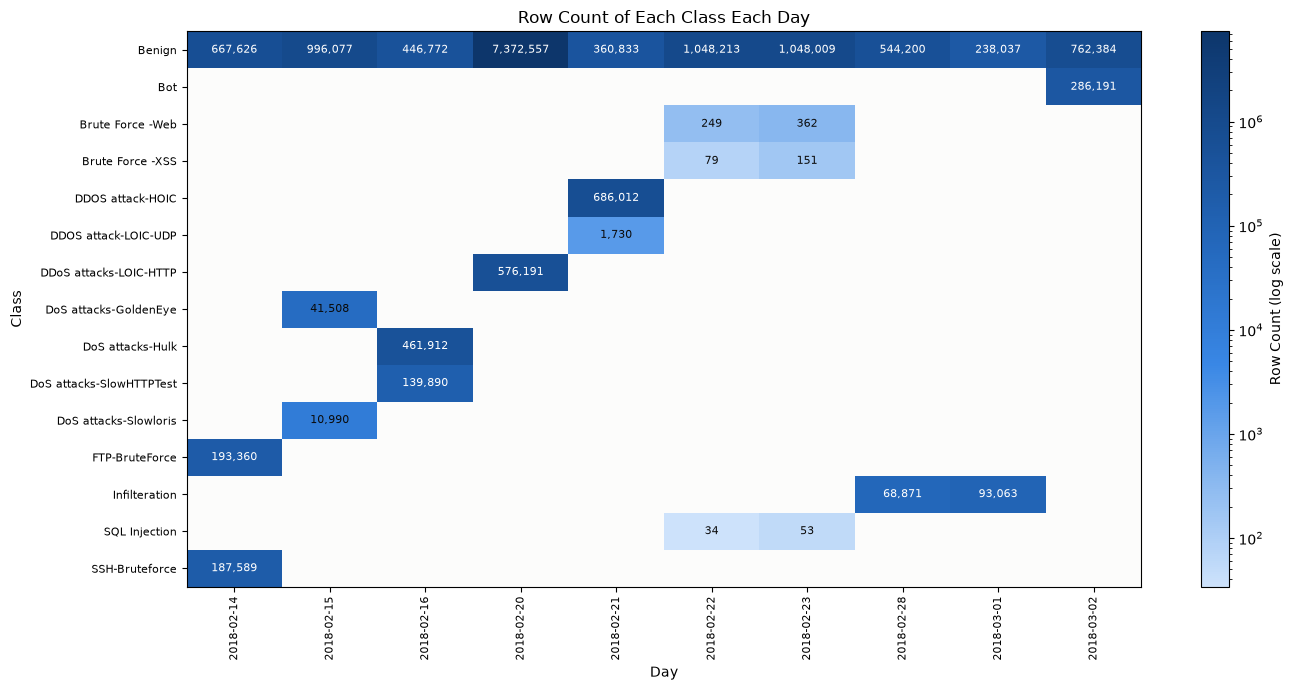

In [76]:
plot_heatmap(
    results.set_index(DAY_COLUMN).T,
    "Row Count of Each Class Each Day",
    xlabel="Day",
    ylabel="Class",
    log_scale=True,
    annotate=True,
    colorbar_label="Row Count (log scale)",
    figsize=(14, 7),
)

### Plot Label Classes (Total)

In [77]:
def count_total_classes(
    class_counts_per_day: pd.DataFrame,
    day_column: str = DAY_COLUMN,
    class_column: str = CLASS_COLUMN,
    row_count_column: str = ROW_COUNT_COLUMN,
    percentage_column: str = PERCENTAGE_COLUMN,
) -> pd.DataFrame:
    totals = class_counts_per_day.drop(columns=day_column).sum()
    totals = totals.rename_axis(class_column).reset_index(name=row_count_column)
    totals[percentage_column] = totals[row_count_column] / totals[row_count_column].sum() * 100
    return totals.sort_values(row_count_column, ascending=False, ignore_index=True)

,class,rows,percentage
0,Benign,13484708,83.070014
1,DDOS attack-HOIC,686012,4.226048
2,DDoS attacks-LOIC-HTTP,576191,3.549517
3,DoS attacks-Hulk,461912,2.845522
4,Bot,286191,1.763026
5,FTP-BruteForce,193360,1.191158
6,SSH-Bruteforce,187589,1.155607
7,Infilteration,161934,0.997564
8,DoS attacks-SlowHTTPTest,139890,0.861766
9,DoS attacks-GoldenEye,41508,0.255702


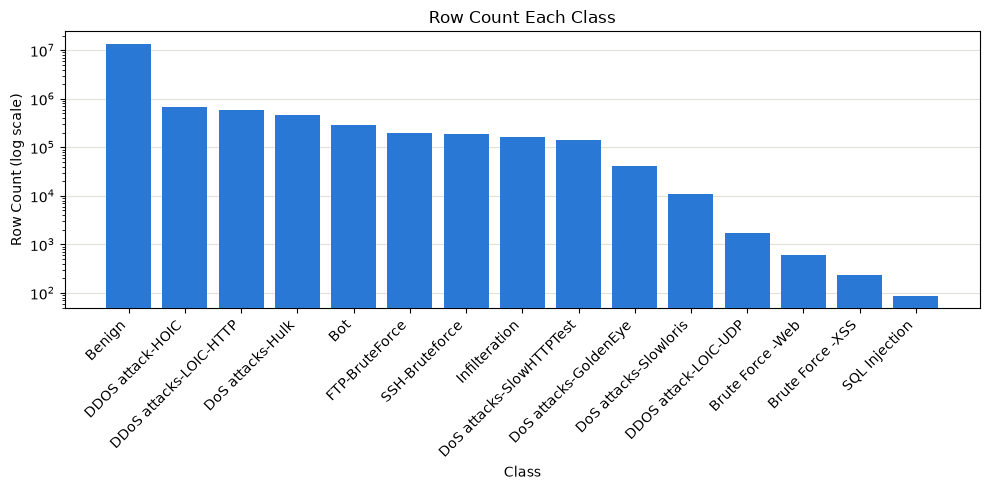

In [78]:
results = count_total_classes(results)
display(results)
plot_bar(
    results,
    CLASS_COLUMN,
    ROW_COUNT_COLUMN,
    "Row Count Each Class",
    "Class",
    "Row Count (log scale)",
    log_scale=True,
)
del results

## Descriptive Statistics

In [79]:
def describe_a_single_feature(
    feature: str,
    folder_path: str = PATH_FOLDER_PARQUET_DATASET,
    feature_column: str = FEATURE_COLUMN,
) -> dict:
    values = pl.col(feature).cast(pl.Float64)
    finite_values = values.filter(values.is_finite())

    statistics = pl.scan_parquet(os.path.join(folder_path, "*.parquet")).select(
        pl.len().alias(ROW_COUNT_COLUMN),
        values.null_count().alias(MISSING_COUNT_COLUMN),
        values.is_nan().sum().alias(NAN_COUNT_COLUMN),
        values.is_infinite().sum().alias(INFINITE_COUNT_COLUMN),
        finite_values.min().alias("min"),
        finite_values.max().alias("max"),
        finite_values.mean().alias("mean"),
        finite_values.median().alias("median"),
        finite_values.std().alias("std"),
        (values < 0).sum().alias("negative"),
        (values == 0).sum().alias("zero"),
        values.drop_nulls().n_unique().alias(UNIQUE_COUNT_COLUMN),
    )
    return {feature_column: feature, **statistics.collect().row(0, named=True)}

In [80]:
def describe_all_features(folder_path: str = PATH_FOLDER_PARQUET_DATASET) -> pd.DataFrame:
    feature_columns = get_feature_columns(folder_path)

    records = []
    started = time.time()
    for feature_index, feature in enumerate(feature_columns, start=1):
        records.append(describe_a_single_feature(feature, folder_path))
        print_progress(feature_index, len(feature_columns), prefix="Describing features", started=started)

    end_status(f"Described {len(feature_columns)} features")
    return pd.DataFrame(records)

In [81]:
descriptive_statistics = describe_all_features()
with pd.option_context("display.max_rows", None):
    display(descriptive_statistics)

Described 78 features                                                           


,feature,rows,missing,nan,infinite,min,max,mean,median,std,negative,zero,unique
0,ack_flag_cnt,16232943,0,0,0,0.000000e+00,1.000000e+00,3.316020e-01,0.000000,4.707888e-01,0,10850066,2
1,active_max,16232943,0,0,0,0.000000e+00,1.140000e+08,2.623920e+05,0.000000,3.319230e+06,0,14605586,905146
2,active_mean,16232943,0,0,0,0.000000e+00,1.140000e+08,1.728776e+05,0.000000,2.505927e+06,0,14605586,1192290
3,active_min,16232943,0,0,0,0.000000e+00,1.140000e+08,1.154657e+05,0.000000,2.114145e+06,0,14605586,427163
4,active_std,16232943,0,0,0,0.000000e+00,7.523242e+07,8.644097e+04,0.000000,1.514575e+06,0,15107385,1009594
5,bwd_blk_rate_avg,16232943,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0,16232943,1
6,bwd_byts_b_avg,16232943,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0,16232943,1
7,bwd_header_len,16232943,0,0,0,0.000000e+00,2.462372e+06,1.330935e+02,16.000000,3.265496e+03,0,4148558,7366
8,bwd_iat_max,16232943,0,0,0,0.000000e+00,1.200000e+08,2.612947e+06,0.000000,1.024426e+07,0,9337704,1892963
9,bwd_iat_mean,16232943,0,0,0,0.000000e+00,1.200000e+08,8.241998e+05,0.000000,4.340497e+06,0,9337704,3875884


## Infinite Values

In [82]:
def find_affected_features(
    descriptive_statistics: pd.DataFrame,
    count_column: str,
    feature_column: str = FEATURE_COLUMN,
    row_count_column: str = ROW_COUNT_COLUMN,
    percentage_column: str = PERCENTAGE_COLUMN,
) -> pd.DataFrame:
    is_affected = descriptive_statistics[count_column] > 0
    columns = [feature_column, count_column, row_count_column]
    affected = descriptive_statistics.loc[is_affected, columns].copy()
    affected[percentage_column] = affected[count_column] / affected[row_count_column] * 100
    affected = affected.drop(columns=row_count_column)
    return affected.sort_values(count_column, ascending=False, ignore_index=True)

In [83]:
results = find_affected_features(descriptive_statistics, INFINITE_COUNT_COLUMN)
display(results)
del results

,feature,infinite,percentage
0,flow_pkts_s,95760,0.589912
1,flow_byts_s,36039,0.222011


## Missing Values

In [84]:
results = find_affected_features(descriptive_statistics, MISSING_COUNT_COLUMN)
display(results)
del results

,feature,missing,percentage
0,flow_byts_s,59721,0.3679


## NaN

In [85]:
results = find_affected_features(descriptive_statistics, NAN_COUNT_COLUMN)
display(results)
del results

,feature,nan,percentage


## Constant Features

In [86]:
def find_constant_features(
    descriptive_statistics: pd.DataFrame,
    feature_column: str = FEATURE_COLUMN,
    unique_count_column: str = UNIQUE_COUNT_COLUMN,
) -> pd.DataFrame:
    is_constant = descriptive_statistics[unique_count_column] <= 1
    columns = [feature_column, "min", unique_count_column]
    return descriptive_statistics.loc[is_constant, columns].reset_index(drop=True)

In [87]:
results = find_constant_features(descriptive_statistics)
display(results)
del results

,feature,min,unique
0,bwd_blk_rate_avg,0.0,1
1,bwd_byts_b_avg,0.0,1
2,bwd_pkts_b_avg,0.0,1
3,bwd_psh_flags,0.0,1
4,bwd_urg_flags,0.0,1
5,fwd_blk_rate_avg,0.0,1
6,fwd_byts_b_avg,0.0,1
7,fwd_pkts_b_avg,0.0,1


## Correlation Heatmaps

In [ ]:
def get_varying_features(
    descriptive_statistics: pd.DataFrame,
    feature_column: str = FEATURE_COLUMN,
    unique_count_column: str = UNIQUE_COUNT_COLUMN,
) -> list[str]:
    is_varying = descriptive_statistics[unique_count_column] > 1
    return descriptive_statistics.loc[is_varying, feature_column].tolist()

In [ ]:
def compute_covariance_in_a_single_file(
    file_path: str,
    feature_columns: list[str],
) -> tuple[int, np.ndarray, np.ndarray]:
    features = pd.read_parquet(file_path, columns=feature_columns).to_numpy(dtype=np.float64)
    features = features[np.isfinite(features).all(axis=1)]

    row_count = len(features)
    if row_count == 0:
        feature_count = len(feature_columns)
        return 0, np.zeros(feature_count), np.zeros((feature_count, feature_count))

    mean = features.mean(axis=0)
    features -= mean
    return row_count, mean, features.T @ features

In [ ]:
def merge_covariance_statistics(first: tuple, second: tuple) -> tuple:
    first_row_count, first_mean, first_cross_products = first
    second_row_count, second_mean, second_cross_products = second

    row_count = first_row_count + second_row_count
    if row_count == 0:
        return first

    delta = second_mean - first_mean
    mean = first_mean + delta * second_row_count / row_count
    correction = np.outer(delta, delta) * first_row_count * second_row_count / row_count
    cross_products = first_cross_products + second_cross_products + correction
    return row_count, mean, cross_products

In [91]:
def compute_correlation_in_all_files(
    feature_columns: list[str],
    folder_path: str = PATH_FOLDER_PARQUET_DATASET,
    n_jobs: int = EDA_N_JOBS,
) -> pd.DataFrame:
    file_paths = get_file_paths_in_folder(folder_path, "parquet")
    tasks = create_tasks_list(compute_covariance_in_a_single_file, file_paths, feature_columns)

    results = run_tasks_in_parallel(tasks, n_jobs, f"Correlating {len(feature_columns)} features")
    end_status(f"Correlated {len(feature_columns)} features in {len(tasks)} files")

    total = results[0]
    for result in results[1:]:
        total = merge_covariance_statistics(total, result)

    _, _, cross_products = total
    standard_deviations = np.sqrt(np.diag(cross_products))
    correlation = cross_products / np.outer(standard_deviations, standard_deviations)
    return pd.DataFrame(correlation, index=feature_columns, columns=feature_columns)

In [ ]:
def find_highly_correlated_pairs(
    correlation: pd.DataFrame,
    threshold: float = CORRELATION_THRESHOLD,
    feature_column: str = FEATURE_COLUMN,
    correlation_column: str = CORRELATION_COLUMN,
) -> pd.DataFrame:
    other_feature_column = f"other_{feature_column}"
    features = correlation.columns.tolist()

    records = []
    for first_index in range(len(features)):
        for second_index in range(first_index + 1, len(features)):
            value = correlation.iat[first_index, second_index]
            if abs(value) >= threshold:
                record = {
                    feature_column: features[first_index],
                    other_feature_column: features[second_index],
                    correlation_column: value,
                }
                records.append(record)

    pairs = pd.DataFrame(records, columns=[feature_column, other_feature_column, correlation_column])
    return pairs.sort_values(correlation_column, key=abs, ascending=False, ignore_index=True)

Correlated 70 features in 168 files                                             


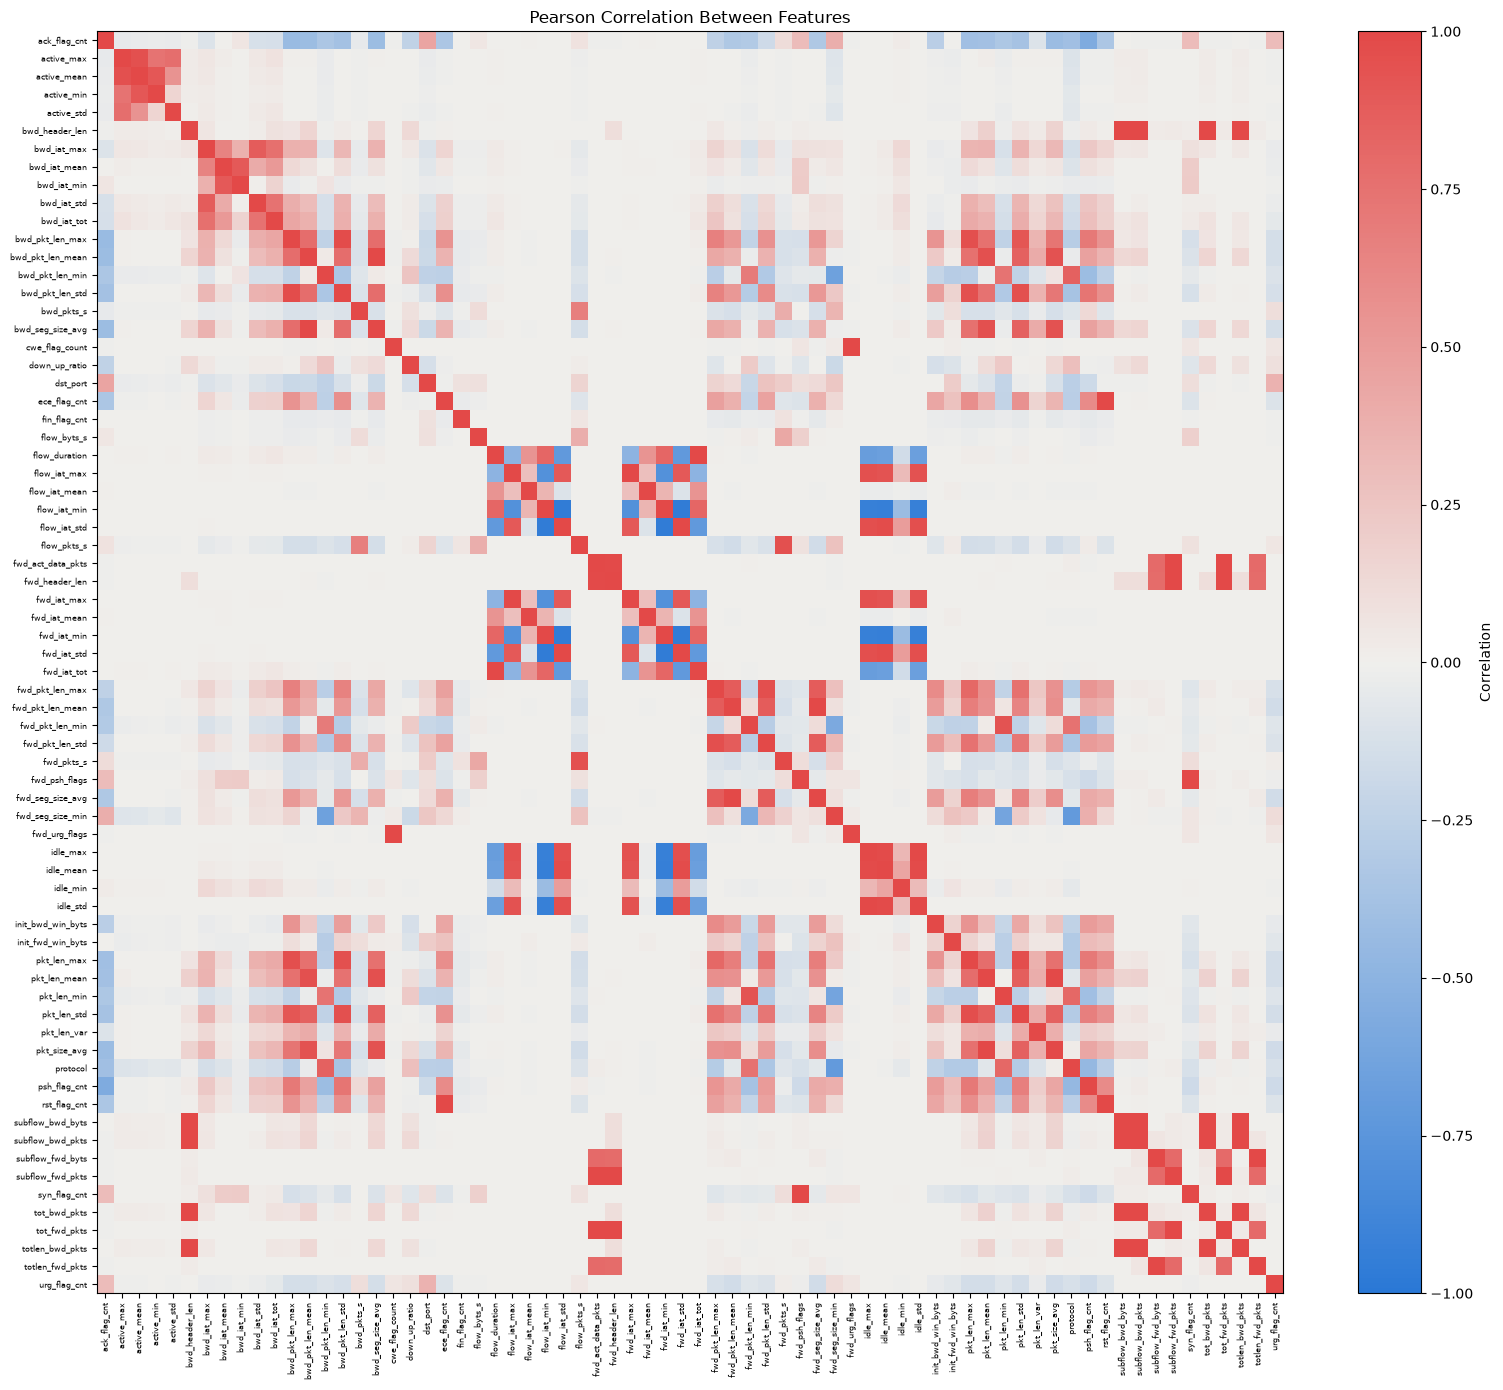

In [93]:
correlation = compute_correlation_in_all_files(get_varying_features(descriptive_statistics))
plot_heatmap(
    correlation,
    "Pearson Correlation Between Features",
    colormap=DIVERGING_COLORMAP,
    value_range=(-1, 1),
    colorbar_label="Correlation",
    figsize=(16, 14),
    font_size=6,
)

### Highly Correlated Features

In [94]:
results = find_highly_correlated_pairs(correlation)
with pd.option_context("display.max_rows", None):
    display(results)
del results, correlation, descriptive_statistics

,feature,other_feature,correlation
0,subflow_bwd_pkts,tot_bwd_pkts,1.000000
1,fwd_psh_flags,syn_flag_cnt,1.000000
2,fwd_pkt_len_mean,fwd_seg_size_avg,1.000000
3,subflow_fwd_pkts,tot_fwd_pkts,1.000000
4,cwe_flag_count,fwd_urg_flags,1.000000
5,bwd_pkt_len_mean,bwd_seg_size_avg,1.000000
6,subflow_fwd_byts,totlen_fwd_pkts,1.000000
7,subflow_bwd_byts,totlen_bwd_pkts,1.000000
8,flow_iat_min,fwd_iat_min,0.999996
9,flow_iat_max,fwd_iat_max,0.999994


# Data Cleaning

In [ ]:
CONSTANT_FEATURES = [
    "bwd_blk_rate_avg",
    "bwd_byts_b_avg",
    "bwd_pkts_b_avg",
    "bwd_psh_flags",
    "bwd_urg_flags",
    "fwd_blk_rate_avg",
    "fwd_byts_b_avg",
    "fwd_pkts_b_avg",
]

ROWS_BEFORE_COLUMN = "rows_before"
MISSING_ROWS_COLUMN = "missing_rows_removed"
INFINITE_ROWS_COLUMN = "infinite_rows_removed"
ROWS_AFTER_COLUMN = "rows_after"

CLEANING_N_JOBS = 8

## Remove Constant Features

In [ ]:
def remove_constant_features(
    dataframe: pd.DataFrame,
    constant_features: list[str] = CONSTANT_FEATURES,
) -> pd.DataFrame:
    return dataframe.drop(columns=constant_features)

## Remove Missing Values

In [ ]:
def remove_missing_value_rows(dataframe: pd.DataFrame) -> pd.DataFrame:
    return dataframe.dropna()

## Remove Infinite Values

In [ ]:
def remove_infinite_value_rows(dataframe: pd.DataFrame) -> pd.DataFrame:
    numeric_columns = dataframe.select_dtypes("number").columns
    has_infinite_value = np.isinf(dataframe[numeric_columns]).any(axis=1)
    return dataframe[~has_infinite_value]

## Clean A Single File

In [ ]:
def clean_a_single_file(
    file_path: str,
    output_folder_path: str = PATH_FOLDER_CLEANED_DATASET,
    constant_features: list[str] = CONSTANT_FEATURES,
    file_column: str = FILE_COLUMN,
) -> dict:
    dataframe = pd.read_parquet(file_path)
    row_count_before = len(dataframe)

    dataframe = remove_constant_features(dataframe, constant_features)
    dataframe = remove_missing_value_rows(dataframe)
    row_count_after_missing = len(dataframe)
    dataframe = remove_infinite_value_rows(dataframe)
    row_count_after = len(dataframe)

    file_name = os.path.basename(file_path)
    os.makedirs(output_folder_path, exist_ok=True)
    dataframe.to_parquet(os.path.join(output_folder_path, file_name), index=False)

    return {
        file_column: file_name,
        ROWS_BEFORE_COLUMN: row_count_before,
        MISSING_ROWS_COLUMN: row_count_before - row_count_after_missing,
        INFINITE_ROWS_COLUMN: row_count_after_missing - row_count_after,
        ROWS_AFTER_COLUMN: row_count_after,
    }

## Clean All Files

In [ ]:
def clean_all_files(
    input_folder_path: str = PATH_FOLDER_PARQUET_DATASET,
    output_folder_path: str = PATH_FOLDER_CLEANED_DATASET,
    n_jobs: int = CLEANING_N_JOBS,
) -> pd.DataFrame:
    file_paths = get_file_paths_in_folder(input_folder_path, "parquet")
    tasks = create_tasks_list(clean_a_single_file, file_paths, output_folder_path)

    records = run_tasks_in_parallel(tasks, n_jobs, "Cleaning files")
    summary = pd.DataFrame(records)

    rows_before = summary[ROWS_BEFORE_COLUMN].sum()
    rows_after = summary[ROWS_AFTER_COLUMN].sum()
    end_status(f"Cleaned {len(tasks)} files: {rows_before:,} rows -> {rows_after:,} rows")
    return summary

## Cleaning

In [ ]:
results = group_and_sum(clean_all_files(), FILE_COLUMN, DAY_COLUMN, DAY_REGEX)
display(results)
del results

# Remove Duplicate Values

In [ ]:
DUPLICATE_ROWS_COLUMN = "duplicate_rows_removed"

ROW_HASH_SEEDS = (0, 1)
DEDUPLICATION_N_JOBS = 8

## Hash Rows

In [ ]:
def hash_rows_in_a_single_file(
    file_path: str,
    hash_seeds: tuple[int, ...] = ROW_HASH_SEEDS,
) -> np.ndarray:
    row = pl.struct(pl.all())
    hash_columns = []
    for hash_seed in hash_seeds:
        hash_columns.append(row.hash(hash_seed).alias(f"hash_{hash_seed}"))
    return pl.read_parquet(file_path).select(hash_columns).to_numpy()

In [ ]:
def hash_rows_in_all_files(
    file_paths: list[str],
    n_jobs: int = DEDUPLICATION_N_JOBS,
) -> list[np.ndarray]:
    tasks = create_tasks_list(hash_rows_in_a_single_file, file_paths)
    return run_tasks_in_parallel(tasks, n_jobs, "Hashing rows")

## Find Duplicate Rows

In [ ]:
def find_duplicate_rows(row_hashes: list[np.ndarray]) -> np.ndarray:
    hashes = pd.DataFrame(np.concatenate(row_hashes))
    return hashes.duplicated(keep="first").to_numpy()

In [ ]:
def get_row_offsets(file_paths: list[str], per_file_rows: list[np.ndarray]) -> dict[str, int]:
    row_offsets = {}
    row_offset = 0
    for file_path, file_rows in zip(file_paths, per_file_rows):
        row_offsets[os.path.basename(file_path)] = row_offset
        row_offset += len(file_rows)
    return row_offsets

## Remove Duplicates In A Single File

In [ ]:
def remove_duplicate_rows_in_a_single_file(
    file_path: str,
    is_duplicate: np.ndarray,
    row_offsets: dict[str, int],
    output_folder_path: str = PATH_FOLDER_DEDUPLICATED_DATASET,
    file_column: str = FILE_COLUMN,
) -> dict:
    file_name = os.path.basename(file_path)
    dataframe = pd.read_parquet(file_path)
    row_count_before = len(dataframe)

    row_offset = row_offsets[file_name]
    is_duplicate_in_file = is_duplicate[row_offset:row_offset + row_count_before]
    dataframe = dataframe[~is_duplicate_in_file]
    row_count_after = len(dataframe)

    os.makedirs(output_folder_path, exist_ok=True)
    dataframe.to_parquet(os.path.join(output_folder_path, file_name), index=False)

    return {
        file_column: file_name,
        ROWS_BEFORE_COLUMN: row_count_before,
        DUPLICATE_ROWS_COLUMN: row_count_before - row_count_after,
        ROWS_AFTER_COLUMN: row_count_after,
    }

## Remove Duplicates In All Files

In [ ]:
def remove_duplicate_rows_in_all_files(
    input_folder_path: str = PATH_FOLDER_CLEANED_DATASET,
    output_folder_path: str = PATH_FOLDER_DEDUPLICATED_DATASET,
    n_jobs: int = DEDUPLICATION_N_JOBS,
) -> pd.DataFrame:
    file_paths = get_file_paths_in_folder(input_folder_path, "parquet")

    row_hashes = hash_rows_in_all_files(file_paths, n_jobs)
    print_status("Finding duplicate rows")
    is_duplicate = find_duplicate_rows(row_hashes)
    row_offsets = get_row_offsets(file_paths, row_hashes)
    del row_hashes

    tasks = create_tasks_list(
        remove_duplicate_rows_in_a_single_file,
        file_paths,
        is_duplicate,
        row_offsets,
        output_folder_path,
    )
    records = run_tasks_in_parallel(tasks, n_jobs, f"Removing {is_duplicate.sum():,} duplicate rows")
    summary = pd.DataFrame(records)

    rows_before = summary[ROWS_BEFORE_COLUMN].sum()
    rows_after = summary[ROWS_AFTER_COLUMN].sum()
    end_status(f"Removed duplicates from {len(tasks)} files: {rows_before:,} rows -> {rows_after:,} rows")
    return summary

## Deduplication

In [ ]:
results = group_and_sum(remove_duplicate_rows_in_all_files(), FILE_COLUMN, DAY_COLUMN, DAY_REGEX)
display(results)
del results

## Class Distribution After Deduplication

In [ ]:
results = group_and_sum(
    count_classes_in_all_files(PATH_FOLDER_DEDUPLICATED_DATASET),
    FILE_COLUMN,
    DAY_COLUMN,
    DAY_REGEX,
)
results = count_total_classes(results)
display(results)
del results

# Splitting Datasets (Train, Dev/Val, Test)

In [97]:
TEST_SIZE = 0.2

In [98]:
TRAIN_ROWS_COLUMN = "train_rows"
TEST_ROWS_COLUMN = "test_rows"
TEST_PERCENTAGE_COLUMN = "test_percentage"

## Assign Test Rows

In [ ]:
def assign_test_rows(
    dataset: pl.LazyFrame,
    label_column: str = LABEL_COLUMN,
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE,
) -> pl.Series:
    label_codes = pl.col(label_column).cast(pl.Enum(load_classes_list())).to_physical()
    labels = dataset.select(label_codes).collect().to_series().to_numpy()

    row_indices = np.arange(len(labels))
    _, test_row_indices = train_test_split(
        row_indices,
        test_size=test_size,
        stratify=labels,
        random_state=random_state,
    )
    return pl.Series(ROW_INDEX_COLUMN, test_row_indices).cast(pl.get_index_type())

## Write Features And Labels

In [ ]:
def write_features_and_labels(
    split: pl.LazyFrame,
    split_folder_path: str,
    label_column: str = LABEL_COLUMN,
    row_index_column: str = ROW_INDEX_COLUMN,
) -> None:
    os.makedirs(split_folder_path, exist_ok=True)

    features = split.drop(row_index_column, label_column)
    labels = split.select(label_column)
    features.sink_parquet(os.path.join(split_folder_path, FEATURES_FILE_NAME))
    labels.sink_parquet(os.path.join(split_folder_path, LABELS_FILE_NAME))

## Split Dataset

In [ ]:
def split_dataset(
    input_folder_path: str = PATH_FOLDER_DEDUPLICATED_DATASET,
    train_folder_path: str = PATH_FOLDER_SPLITTED_DATASET_TRAIN,
    test_folder_path: str = PATH_FOLDER_SPLITTED_DATASET_TEST,
    row_index_column: str = ROW_INDEX_COLUMN,
) -> None:
    dataset = load_all_files(input_folder_path, row_index_column)
    row_count = dataset.select(pl.len()).collect().item()

    print_status(f"Assigning {row_count:,} rows to train and test")
    test_row_indices = assign_test_rows(dataset)
    is_test_row = pl.col(row_index_column).is_in(test_row_indices.implode())

    print_status("Writing the train split")
    write_features_and_labels(dataset.filter(~is_test_row), train_folder_path)
    print_status("Writing the test split")
    write_features_and_labels(dataset.filter(is_test_row), test_folder_path)

    test_row_count = len(test_row_indices)
    train_row_count = row_count - test_row_count
    end_status(f"Split {row_count:,} rows: {train_row_count:,} train rows, {test_row_count:,} test rows")

## Splitting

In [ ]:
split_dataset()

## Class Distribution Per Split

In [99]:
def summarize_split_classes(
    train_folder_path: str = PATH_FOLDER_SPLITTED_DATASET_TRAIN,
    test_folder_path: str = PATH_FOLDER_SPLITTED_DATASET_TEST,
    class_column: str = CLASS_COLUMN,
) -> pd.DataFrame:
    summary = pd.DataFrame({
        TRAIN_ROWS_COLUMN: count_classes_in_split(train_folder_path),
        TEST_ROWS_COLUMN: count_classes_in_split(test_folder_path),
    })
    total_rows = summary[TRAIN_ROWS_COLUMN] + summary[TEST_ROWS_COLUMN]
    summary[TEST_PERCENTAGE_COLUMN] = summary[TEST_ROWS_COLUMN] / total_rows * 100

    summary = summary.rename_axis(class_column).reset_index()
    return summary.sort_values(TRAIN_ROWS_COLUMN, ascending=False, ignore_index=True)

In [100]:
results = summarize_split_classes()
display(results)
del results

,class,train_rows,test_rows,test_percentage
0,Benign,8076122,2019030,19.999996
1,DDoS attacks-LOIC-HTTP,460010,115002,19.999930
2,DDOS attack-HOIC,159089,39772,19.999899
3,DoS attacks-Hulk,116159,29040,20.000138
4,Bot,115628,28907,20.000000
5,Infilteration,111473,27868,19.999856
6,SSH-Bruteforce,75238,18810,20.000425
7,DoS attacks-GoldenEye,33114,8278,19.999034
8,DoS attacks-Slowloris,7770,1942,19.995881
9,DDOS attack-LOIC-UDP,1384,346,20.000000


# Encode Classes' Label

## Load and Dump LabelEncoder

In [41]:
def load_label_encoder(label_encoder_path:str = PATH_LABEL_ENCODER_TRANSFORMER) -> LabelEncoder:
    return load(label_encoder_path)

In [42]:
def dump_label_encoder(label_encoder:LabelEncoder,label_encoder_path:str = PATH_LABEL_ENCODER_TRANSFORMER) -> None:
    dump(label_encoder,label_encoder_path)

## Make Label Encoder

In [43]:
def create_label_encoding()->LabelEncoder:
    encoder = LabelEncoder()
    classes_list = load_classes_list()
    encoder.fit(classes_list)
    dump_label_encoder(encoder)
    return encoder

In [54]:
create_label_encoding()

LabelEncoder()

## Encode and Decode Labels

In [58]:
def encode_labels(dataframe: pd.DataFrame, column: str = LABEL_COLUMN) -> pd.DataFrame:
    encoder = load_label_encoder()
    df = dataframe.copy()
    df[column] = encoder.transform(dataframe[column])
    return df

In [59]:
def encode_polar_labels(dataset: pl.LazyFrame, column: str = LABEL_COLUMN) -> pl.LazyFrame:
    classes = load_label_encoder().classes_.tolist()
    codes = list(range(len(classes)))
    return dataset.with_columns(pl.col(column).replace_strict(classes, codes, return_dtype=pl.Int64))

In [60]:
def decode_labels(dataframe: pd.DataFrame, column: str = LABEL_COLUMN) -> pd.DataFrame:
    encoder = load_label_encoder()
    df = dataframe.copy()
    df[column] = encoder.inverse_transform(df[column].astype(int))
    return df

## Encode Train and Test Labels

In [61]:
def encode_train_and_test_labels(output_name:str=ENCODED_LABELS_FILE_NAME):
    for folder in (PATH_FOLDER_SPLITTED_DATASET_TRAIN, PATH_FOLDER_SPLITTED_DATASET_TEST):
        print_status(f"Encoding labels in {folder}")
        labels = pl.scan_parquet(os.path.join(folder, LABELS_FILE_NAME))
        encode_polar_labels(labels).sink_parquet(os.path.join(folder, output_name))
    end_status("Encoded labels in the train and test splits")

In [62]:
encode_train_and_test_labels()

# Pipeline

In [57]:
PCA_VARIANCE_THRESHOLD = 0.95
CUML_VERBOSE = 3  # cuML logs warnings and errors only

## Shared Steps

In [58]:
class ProgressPipeline(Pipeline):
    def fit(self, X, y=None, progress: Any = None, **params):
        self.progress_ = progress
        try:
            super().fit(X, y, **params)
        except Exception:
            self.report_progress("failed")
            raise
        self.report_progress("fitted")
        return self

    # the scorers predict the validation rows after every fit, and for KNN that takes far longer than the fit
    def predict(self, X, **params):
        try:
            predictions = super().predict(X, **params)
        except Exception:
            self.report_progress("failed")
            raise
        self.report_progress("scored")
        return predictions

    def report_progress(self, event: str) -> None:
        progress = getattr(self, "progress_", None)
        if progress is None:
            return
        progress.put(event)
        if event != "fitted":
            self.progress_ = None  # each fit ends once, although every scorer retries a failed predict

In [59]:
def make_preprocessing_steps(pca_variance_threshold: float = PCA_VARIANCE_THRESHOLD) -> list[tuple[str, Any]]:
    return [
        ("cast", FunctionTransformer(_to_float32)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=pca_variance_threshold, random_state=RANDOM_STATE)),
    ]

In [60]:
def make_model_pipeline(model_name: str, model: Any, use_smote: bool = True) -> Pipeline:
    steps = make_preprocessing_steps()
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append((model_name, model))
    return ProgressPipeline(steps)

## K-Nearest-Neighbors

In [61]:
def make_knn_pipeline(use_smote: bool = True) -> Pipeline:
    return make_model_pipeline("knn", KNeighborsClassifier(verbose=CUML_VERBOSE), use_smote)

## Support Vector Machine

In [62]:
SVM_STALL_ERROR = "Working set has already been initialized"
SVM_RETRY_CACHE_SIZES = [512.0, 2048.0, 3072.0]

In [63]:
class RetrySVC(SVC):
    """cuML SVC that refits with other kernel cache sizes when cuML's SMO solver stalls.

    The stall ("Working set has already been initialized!") is a cuML bug. The cache size
    changes the order the solver visits the working set, so a refit often gets past it.
    """

    def fit(self, X, y, sample_weight=None):
        cache_size = self.cache_size
        try:
            for retry_cache_size in [cache_size, *SVM_RETRY_CACHE_SIZES]:
                self.cache_size = retry_cache_size
                try:
                    return super().fit(X, y, sample_weight)
                except RuntimeError as error:
                    if SVM_STALL_ERROR not in str(error):
                        raise
            raise RuntimeError(f"{SVM_STALL_ERROR} with every cache size in {SVM_RETRY_CACHE_SIZES}")
        finally:
            self.cache_size = cache_size

In [64]:
def make_svm_pipeline(use_smote: bool = True) -> Pipeline:
    return make_model_pipeline("svm", RetrySVC(verbose=CUML_VERBOSE), use_smote)

## Random Forest

In [65]:
def make_rf_pipeline(use_smote: bool = True) -> Pipeline:
    model = RandomForestClassifier(random_state=RANDOM_STATE, verbose=CUML_VERBOSE)
    return make_model_pipeline("rf", model, use_smote)

## Extreme Gradient Boost

In [66]:
def make_xgb_pipeline(use_smote: bool = True) -> Pipeline:
    model = XGBClassifier(
        device="cuda" if USE_CUDA else "cpu",
        tree_method="hist",
        max_bin=128,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )
    return make_model_pipeline("xgb", model, use_smote)

## Logistic Regression (LogRes) or Softmax

In [67]:
def make_logreg_pipeline(use_smote: bool = True) -> Pipeline:
    return make_model_pipeline("logreg", LogisticRegression(verbose=CUML_VERBOSE), use_smote)

# Grid Search CV

In [68]:
N_SPLITS = 5
VALIDATION_SIZE = 0.2

# rows each grid search is tuned on, None tunes on the full train split (the final model always uses the full split)
GRID_SEARCH_SAMPLE_SIZES = {
    "knn": 250_000,
    "svm": 200_000,
    "rf": 1_000_000,
    "xgb": 1_000_000,
    "logreg": 1_000_000,
}
MIN_ROWS_PER_CLASS = 20

In [ ]:
GRID_SEARCH_SCORING = {
    "f1_macro": partial(f1_score, average="macro", zero_division=0),
    "precision_macro": partial(precision_score, average="macro", zero_division=0),
    "recall_macro": partial(recall_score, average="macro", zero_division=0),
    "f1_weighted": partial(f1_score, average="weighted", zero_division=0),
    "precision_weighted": partial(precision_score, average="weighted", zero_division=0),
    "recall_weighted": partial(recall_score, average="weighted", zero_division=0),
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "mcc": matthews_corrcoef,
    "cohen_kappa": cohen_kappa_score,
}
GRID_SEARCH_RANK_METRIC = "f1_macro"
GRID_SEARCH_N_JOBS = 1

In [70]:
USE_SMOTE = False
SMOTE_K_NEIGHBORS_GRID = [3, 5, 7]

## Load Train Split

In [71]:
def load_labels(
    split_folder_path: str,
    labels_file_name: str = ENCODED_LABELS_FILE_NAME,
    label_column: str = LABEL_COLUMN,
) -> pd.Series:
    labels = pl.scan_parquet(os.path.join(split_folder_path, labels_file_name)).select(label_column)
    return labels.collect().to_series().to_pandas()

In [ ]:
def load_split(
    split_folder_path: str,
    features_file_name: str = FEATURES_FILE_NAME,
    labels_file_name: str = ENCODED_LABELS_FILE_NAME,
    label_column: str = LABEL_COLUMN,
) -> tuple[pd.DataFrame, pd.Series]:
    features = pl.scan_parquet(os.path.join(split_folder_path, features_file_name))
    features = load_features(features, f"Loading {split_folder_path}")
    labels = load_labels(split_folder_path, labels_file_name, label_column)
    if len(features) != len(labels):
        raise ValueError(f"{split_folder_path}: {len(features):,} feature rows but {len(labels):,} labels")
    return features, labels

In [72]:
train_features, train_labels = load_split(PATH_FOLDER_SPLITTED_DATASET_TRAIN)
end_status(f"Loaded {len(train_labels):,} train rows x {train_features.shape[1]} features")

Loaded 9,156,764 train rows x 70 features                                       


## Principal Components Check

In [73]:
COMPONENT_COLUMN = "component"
EXPLAINED_VARIANCE_COLUMN = "explained_variance_percentage"
CUMULATIVE_VARIANCE_COLUMN = "cumulative_variance_percentage"

In [74]:
def fit_principal_components(features: pd.DataFrame) -> PCA:
    print_status(f"Fitting the scaler and PCA on {len(features):,} rows")
    preprocessing = Pipeline(make_preprocessing_steps()).fit(features)
    return preprocessing.named_steps["pca"]

In [75]:
def summarize_explained_variance(pca: PCA) -> pd.DataFrame:
    component_count = len(pca.explained_variance_ratio_)
    return pd.DataFrame({
        COMPONENT_COLUMN: np.arange(1, component_count + 1),
        EXPLAINED_VARIANCE_COLUMN: pca.explained_variance_ratio_ * 100,
        CUMULATIVE_VARIANCE_COLUMN: np.cumsum(pca.explained_variance_ratio_) * 100,
    })

In [76]:
pca = fit_principal_components(train_features)
results = summarize_explained_variance(pca)
kept_variance = results[CUMULATIVE_VARIANCE_COLUMN].iloc[-1]
end_status(
    f"{pca.n_components_} principal components keep {kept_variance:.2f}% of the variance "
    f"(more than {PCA_VARIANCE_THRESHOLD:.0%})"
)
with pd.option_context("display.max_rows", None):
    display(results)
del pca, results, kept_variance

25 principal components keep 95.59% of the variance (more than 95%)             


,component,explained_variance_percentage,cumulative_variance_percentage
0,1,16.029911,16.029911
1,2,13.415505,29.445415
2,3,7.875618,37.321033
3,4,7.173468,44.494503
4,5,6.328940,50.823444
5,6,5.199128,56.022572
6,7,4.719165,60.741734
7,8,4.460383,65.202118
8,9,3.687749,68.889870
9,10,3.328786,72.218658


## Parameter Grid

In [77]:
def make_param_grid(
    model_param_grid: dict | list[dict],
    use_smote: bool = True,
    smote_k_neighbors: list[int] = SMOTE_K_NEIGHBORS_GRID,
) -> list[dict]:
    if isinstance(model_param_grid, dict):
        model_param_grid = [model_param_grid]

    shared_param_grid = {}
    if use_smote:
        shared_param_grid["smote__k_neighbors"] = smote_k_neighbors

    param_grid = []
    for model_params in model_param_grid:
        param_grid.append({**shared_param_grid, **model_params})
    return param_grid

## Grid Search Sample

In [ ]:
FULL_ROWS_COLUMN = "full_rows"
FULL_PERCENTAGE_COLUMN = "full_percentage"
SAMPLE_ROWS_COLUMN = "sample_rows"
SAMPLE_PERCENTAGE_COLUMN = "sample_percentage"

In [ ]:
def make_search_sample(
    features: pd.DataFrame,
    labels: pd.Series,
    sample_size: int | None,
    random_state: int = RANDOM_STATE,
    min_rows_per_class: int = MIN_ROWS_PER_CLASS,
) -> tuple[pd.DataFrame, pd.Series]:
    if sample_size is None or sample_size >= len(labels):
        return features, labels

    label_values = labels.to_numpy()
    classes, class_counts = np.unique(label_values, return_counts=True)
    # sampled per class by hand, because train_test_split(stratify=...) can round the rarest classes down to 0 rows
    quotas = np.round(class_counts * sample_size / len(labels)).astype(int)
    quotas = np.maximum(quotas, np.minimum(class_counts, min_rows_per_class))

    rng = np.random.default_rng(random_state)
    sample_rows = []
    for class_code, quota in zip(classes, quotas):
        class_rows = np.flatnonzero(label_values == class_code)
        sample_rows.append(rng.choice(class_rows, size=quota, replace=False))
    sample_rows = np.sort(np.concatenate(sample_rows))

    sample_features = features.iloc[sample_rows].reset_index(drop=True)
    sample_labels = labels.iloc[sample_rows].reset_index(drop=True)
    return sample_features, sample_labels

In [ ]:
def summarize_sample_classes(
    labels: pd.Series,
    sample_labels: pd.Series,
    class_column: str = CLASS_COLUMN,
) -> pd.DataFrame:
    summary = pd.DataFrame({
        FULL_ROWS_COLUMN: labels.value_counts(),
        SAMPLE_ROWS_COLUMN: sample_labels.value_counts(),
    }).fillna(0).astype(int)
    summary[FULL_PERCENTAGE_COLUMN] = summary[FULL_ROWS_COLUMN] / summary[FULL_ROWS_COLUMN].sum() * 100
    summary[SAMPLE_PERCENTAGE_COLUMN] = summary[SAMPLE_ROWS_COLUMN] / summary[SAMPLE_ROWS_COLUMN].sum() * 100

    summary.index = load_label_encoder().classes_[summary.index.to_numpy()]
    columns = [FULL_ROWS_COLUMN, FULL_PERCENTAGE_COLUMN, SAMPLE_ROWS_COLUMN, SAMPLE_PERCENTAGE_COLUMN]
    summary = summary[columns].rename_axis(class_column).reset_index()
    return summary.sort_values(FULL_ROWS_COLUMN, ascending=False, ignore_index=True)

## Grid Search Scorer

In [ ]:
CONFUSION_SCORE_PREFIX = "confusion"
CANDIDATE_COLUMN = "candidate"
SPLIT_COLUMN = "split"
TRUE_CLASS_COLUMN = "true_class"

In [ ]:
def get_confusion_score_name(true_code: int, predicted_code: int) -> str:
    return f"{CONFUSION_SCORE_PREFIX}_{true_code}_{predicted_code}"

In [ ]:
class GridSearchScorer:
    def __init__(self, metrics: dict[str, Callable], class_count: int) -> None:
        # a metric that cannot score would only show up as NaN after the whole grid search, so each one is tried first
        for name, metric in metrics.items():
            try:
                metric(np.arange(class_count), np.arange(class_count))
            except Exception as error:
                raise ValueError(f"{name!r} has to be a metric(labels, predictions) function") from error
        self.metrics = metrics
        self.class_count = class_count

    def get_score_names(self) -> list[str]:
        score_names = list(self.metrics)
        for true_code in range(self.class_count):
            for predicted_code in range(self.class_count):
                score_names.append(get_confusion_score_name(true_code, predicted_code))
        return score_names

    def __call__(self, estimator: Any, features: pd.DataFrame, labels: pd.Series) -> dict[str, float]:
        try:
            predictions = np.asarray(estimator.predict(features)).astype(np.int64, copy=False)
            scores = {}
            for name, metric in self.metrics.items():
                scores[name] = metric(labels, predictions)
            matrix = confusion_matrix(labels, predictions, labels=np.arange(self.class_count))
        except Exception as error:
            # a scorer that raises gets a single NaN instead of a dict, and that breaks GridSearchCV after the last fit
            warnings.warn(f"Scoring failed, every score of this fit is NaN: {error!r}")
            return dict.fromkeys(self.get_score_names(), np.nan)

        # cv_results_ only keeps numbers, so every cell of the confusion matrix is passed as a score of its own
        for true_code in range(self.class_count):
            for predicted_code in range(self.class_count):
                scores[get_confusion_score_name(true_code, predicted_code)] = matrix[true_code, predicted_code]
        return scores

## Confusion Matrices and Class Reports

In [ ]:
def get_confusion_columns(split_index: int, class_count: int) -> list[str]:
    columns = []
    for true_code in range(class_count):
        for predicted_code in range(class_count):
            columns.append(f"split{split_index}_test_{get_confusion_score_name(true_code, predicted_code)}")
    return columns

In [ ]:
def make_class_report(matrix: np.ndarray, class_names: list[str]) -> pd.DataFrame:
    true_rows = matrix.sum(axis=1)
    predicted_rows = matrix.sum(axis=0)
    hits = np.diag(matrix)
    with np.errstate(divide="ignore", invalid="ignore"):
        report = pd.DataFrame({
            CLASS_COLUMN: class_names,
            "precision": np.where(predicted_rows > 0, hits / predicted_rows, 0.0),
            "recall": np.where(true_rows > 0, hits / true_rows, 0.0),
            "f1": np.where(true_rows + predicted_rows > 0, 2 * hits / (true_rows + predicted_rows), 0.0),
            "support": true_rows,
        })

    # like the grid search scores, a class that is neither true nor predicted is left out of the macro average
    is_present = true_rows + predicted_rows > 0
    class_scores = report.loc[is_present, ["precision", "recall", "f1"]]
    macro_scores = class_scores.mean()
    weighted_scores = class_scores.mul(true_rows[is_present], axis=0).sum() / true_rows.sum()
    averages = pd.DataFrame({
        CLASS_COLUMN: ["accuracy", "macro avg", "weighted avg"],
        "precision": [np.nan, macro_scores["precision"], weighted_scores["precision"]],
        "recall": [np.nan, macro_scores["recall"], weighted_scores["recall"]],
        "f1": [hits.sum() / true_rows.sum(), macro_scores["f1"], weighted_scores["f1"]],
        "support": true_rows.sum(),
    })
    return pd.concat([report, averages], ignore_index=True)

In [ ]:
def add_fit_columns(table: pd.DataFrame, fit: dict) -> pd.DataFrame:
    for position, (column, value) in enumerate(fit.items()):
        table.insert(position, column, [value] * len(table))
    return table

In [ ]:
def report_every_fit(
    results: pd.DataFrame,
    class_names: list[str],
    n_splits: int = N_SPLITS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    class_count = len(class_names)
    param_columns = []
    for column in results.columns:
        if column.startswith("param_"):
            param_columns.append(column)

    matrix_tables = []
    report_tables = []
    for candidate in results.index:
        fit = {CANDIDATE_COLUMN: candidate}
        for column in param_columns:
            fit[column] = results.loc[candidate, column]
        for split_index in range(n_splits):
            cells = results.loc[candidate, get_confusion_columns(split_index, class_count)].to_numpy(dtype=float)
            if np.isnan(cells).any():
                continue  # the fit failed, so it has no predictions
            matrix = cells.reshape(class_count, class_count).astype(np.int64)
            fit[SPLIT_COLUMN] = split_index

            matrix_table = pd.DataFrame(matrix, columns=class_names)
            matrix_table.insert(0, TRUE_CLASS_COLUMN, class_names)
            matrix_tables.append(add_fit_columns(matrix_table, fit))
            report_tables.append(add_fit_columns(make_class_report(matrix, class_names), fit))

    if not matrix_tables:
        raise ValueError("Every fit of the grid search failed, so there is no confusion matrix to report")
    return pd.concat(matrix_tables, ignore_index=True), pd.concat(report_tables, ignore_index=True)

In [ ]:
def drop_confusion_scores(results: pd.DataFrame) -> pd.DataFrame:
    columns = []
    for column in results.columns:
        if f"_test_{CONFUSION_SCORE_PREFIX}_" not in column:
            columns.append(column)
    return results[columns]

## Run Grid Search

In [78]:
def make_splitter(
    n_splits: int = N_SPLITS,
    validation_size: float = VALIDATION_SIZE,
    random_state: int = RANDOM_STATE,
) -> StratifiedShuffleSplit:
    return StratifiedShuffleSplit(n_splits=n_splits, test_size=validation_size, random_state=random_state)

In [79]:
def get_split_score_columns(rank_metric: str = GRID_SEARCH_RANK_METRIC, n_splits: int = N_SPLITS) -> list[str]:
    columns = []
    for split_index in range(n_splits):
        columns.append(f"split{split_index}_test_{rank_metric}")
    return columns

In [ ]:
def run_grid_search(
    model_name: str,
    pipeline: Pipeline,
    param_grid: list[dict],
    features: pd.DataFrame,
    labels: pd.Series,
    class_count: int,
    scoring: dict[str, Callable] = GRID_SEARCH_SCORING,
    rank_metric: str = GRID_SEARCH_RANK_METRIC,
    n_jobs: int = GRID_SEARCH_N_JOBS,
) -> pd.DataFrame:
    splitter = make_splitter()
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        scoring=GridSearchScorer(scoring, class_count),
        refit=False,  # the best fold model is refitted separately, so a failed refit cannot lose the results
        cv=splitter,
        n_jobs=n_jobs,
    )
    fit_count = len(ParameterGrid(param_grid)) * splitter.get_n_splits()
    progress = GridSearchProgress(fit_count, f"{model_name}: grid search on {len(labels):,} rows")
    try:
        with warnings.catch_warnings():
            # a failed fit makes every confusion matrix cell warn on its own, and the failed fits are counted below
            warnings.filterwarnings("ignore", message="One or more of the test scores are non-finite")
            grid_search.fit(features, labels, progress=progress.events)
    finally:
        progress.close()

    results = pd.DataFrame(grid_search.cv_results_)
    results = results.sort_values(f"rank_test_{rank_metric}", ignore_index=True)

    elapsed = format_duration(time.time() - progress.started)
    failed_count = results[get_split_score_columns(rank_metric)].isna().sum().sum()
    best_score = results.loc[0, f"mean_test_{rank_metric}"]
    end_status(f"{model_name}: {fit_count} fits in {elapsed}, {failed_count} failed, best {rank_metric} {best_score:.4f}")
    return results

In [ ]:
def save_grid_search_results(
    results: pd.DataFrame,
    confusion_matrices: pd.DataFrame,
    class_reports: pd.DataFrame,
    model_name: str,
    use_smote: bool,
    sample_size: int,
    sample_classes: pd.DataFrame,
) -> None:
    if use_smote:
        folder_path = PATH_FOLDER_GRID_SEARCH_WITH_SMOTE
    else:
        folder_path = PATH_FOLDER_GRID_SEARCH_WOUT_SMOTE
    os.makedirs(folder_path, exist_ok=True)

    results.to_csv(os.path.join(folder_path, f"{model_name}.csv"), index=False)
    confusion_matrices.to_csv(os.path.join(folder_path, f"{model_name}-confusion-matrices.csv"), index=False)
    class_reports.to_csv(os.path.join(folder_path, f"{model_name}-class-reports.csv"), index=False)
    sample_classes.to_csv(os.path.join(folder_path, f"{model_name}-sample-classes.csv"), index=False)
    best_params = {"sample_size": sample_size, "params": results.loc[0, "params"]}
    with open(os.path.join(folder_path, f"{model_name}-best-params.json"), "w", encoding="utf-8") as file:
        json.dump(best_params, file, indent=4, default=repr)

In [ ]:
def summarize_grid_search(results: pd.DataFrame, rank_metric: str = GRID_SEARCH_RANK_METRIC) -> pd.DataFrame:
    columns = []
    for column in results.columns:
        if column.startswith(("param_", "mean_test_")):
            columns.append(column)
    columns.append(f"std_test_{rank_metric}")
    columns.append("mean_fit_time")
    return results[columns]

In [ ]:
def search_model(
    model_name: str,
    make_pipeline: Callable[[bool], Pipeline],
    model_param_grid: dict | list[dict],
    features: pd.DataFrame,
    labels: pd.Series,
    use_smote: bool,
    sample_sizes: dict[str, int | None] = GRID_SEARCH_SAMPLE_SIZES,
) -> pd.DataFrame:
    if model_name not in sample_sizes:
        raise KeyError(f"{model_name!r} is missing from GRID_SEARCH_SAMPLE_SIZES, give it a row count or None for the full train split")

    print_status(f"{model_name}: sampling the train split for the grid search")
    sample_features, sample_labels = make_search_sample(features, labels, sample_sizes[model_name])
    sample_classes = summarize_sample_classes(labels, sample_labels)
    kept_classes = (sample_classes[SAMPLE_ROWS_COLUMN] > 0).sum()
    end_status(
        f"{model_name}: grid search sample of {len(sample_labels):,} / {len(labels):,} train rows, "
        f"{kept_classes} / {len(sample_classes)} classes kept"
    )

    class_names = load_label_encoder().classes_.tolist()
    results = run_grid_search(
        model_name,
        make_pipeline(use_smote),
        make_param_grid(model_param_grid, use_smote),
        sample_features,
        sample_labels,
        len(class_names),
    )
    confusion_matrices, class_reports = report_every_fit(results, class_names)
    results = drop_confusion_scores(results)
    save_grid_search_results(
        results,
        confusion_matrices,
        class_reports,
        model_name,
        use_smote,
        len(sample_labels),
        sample_classes,
    )

    del sample_features, sample_labels
    gc.collect()
    return results

## Best Fold Model

In [84]:
def save_best_fold_model(
    model_name: str,
    make_pipeline: Callable[[bool], Pipeline],
    results: pd.DataFrame,
    features: pd.DataFrame,
    labels: pd.Series,
    use_smote: bool,
    rank_metric: str = GRID_SEARCH_RANK_METRIC,
) -> None:
    # the search may have run on a sample whose split indices do not match the full data, so no split is reused here
    print_status(f"{model_name}: fitting the best params on the full train split ({len(labels):,} rows)")
    pipeline = make_pipeline(use_smote).set_params(**clone(results.loc[0, "params"], safe=False))
    pipeline.fit(features, labels)

    if use_smote:
        folder_path = PATH_FOLDER_TRAINED_MODEL_WITH_SMOTE
    else:
        folder_path = PATH_FOLDER_TRAINED_MODEL_WOUT_SMOTE
    os.makedirs(folder_path, exist_ok=True)
    model_path = os.path.join(folder_path, f"{model_name}.pkl")

    print_status(f"{model_name}: saving the model to {model_path}")
    dump(pipeline, model_path)
    best_score = results.loc[0, f"mean_test_{rank_metric}"]
    end_status(
        f"{model_name}: saved the model fitted on {len(labels):,} rows ({pipeline.named_steps['pca'].n_components_} PCs) "
        f"to {model_path}, best mean CV {rank_metric} {best_score:.4f}"
    )

## K-Nearest-Neighbors

In [85]:
# cuML's KNeighborsClassifier only supports weights="uniform"
KNN_PARAM_GRID = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 13],
    "knn__metric": ["manhattan", "euclidean", "cosine"],
}

In [ ]:
knn_results = search_model(
    "knn",
    make_knn_pipeline,
    KNN_PARAM_GRID,
    train_features,
    train_labels,
    USE_SMOTE,
)
display(knn_results.loc[0, "params"])
display(summarize_grid_search(knn_results).head(10))

knn: grid search on 9,156,764 rows |------------------------------| 1/105 (1%) | 00:01:17 elapsed, ~02:13:41 left | 0 failed

In [ ]:
save_best_fold_model(
    "knn",
    make_knn_pipeline,
    knn_results,
    train_features,
    train_labels,
    USE_SMOTE,
)

## Support Vector Machine

In [ ]:

SVM_PARAM_GRID = [
    {"svm__kernel": ["rbf"], "svm__C": [0.1, 1.0, 10.0], "svm__gamma": ["scale", 0.1]},
    {"svm": [LinearSVC(loss="hinge", output_type="numpy", verbose=CUML_VERBOSE)], "svm__C": [0.1, 1.0, 10.0]},
]

In [ ]:
svm_results = search_model(
    "svm",
    make_svm_pipeline,
    SVM_PARAM_GRID,
    train_features,
    train_labels,
    USE_SMOTE,
)
display(svm_results.loc[0, "params"])
display(summarize_grid_search(svm_results).head(10))

In [ ]:
save_best_fold_model(
    "svm",
    make_svm_pipeline,
    svm_results,
    train_features,
    train_labels,
    USE_SMOTE,
)

## Random Forest

In [ ]:
RF_PARAM_GRID = {
    "rf__n_estimators": [100, 300],
    "rf__max_depth": [12, 16, 24],
    "rf__max_features": ["sqrt", "log2"],
}

In [ ]:
rf_results = search_model(
    "rf",
    make_rf_pipeline,
    RF_PARAM_GRID,
    train_features,
    train_labels,
    USE_SMOTE,
)
display(rf_results.loc[0, "params"])
display(summarize_grid_search(rf_results).head(10))

In [ ]:
save_best_fold_model(
    "rf",
    make_rf_pipeline,
    rf_results,
    train_features,
    train_labels,
    USE_SMOTE,
)

## Extreme Gradient Boost

In [ ]:
# GridSearchCV gives no validation set for early stopping, so the tree count is searched instead
XGB_PARAM_GRID = {
    "xgb__n_estimators": [200, 400],
    "xgb__max_depth": [6, 8, 10],
    "xgb__learning_rate": [0.1, 0.3],
    "xgb__colsample_bytree": [0.6, 1.0],
}

In [ ]:
xgb_results = search_model(
    "xgb",
    make_xgb_pipeline,
    XGB_PARAM_GRID,
    train_features,
    train_labels,
    USE_SMOTE,
)
display(xgb_results.loc[0, "params"])
display(summarize_grid_search(xgb_results).head(10))

In [ ]:
save_best_fold_model(
    "xgb",
    make_xgb_pipeline,
    xgb_results,
    train_features,
    train_labels,
    USE_SMOTE,
)

## Logistic Regression (LogRes) or Softmax

In [ ]:
LOGREG_PARAM_GRID = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0],
    "logreg__penalty": ["l1", "l2"],
}

In [ ]:
logreg_results = search_model(
    "logreg",
    make_logreg_pipeline,
    LOGREG_PARAM_GRID,
    train_features,
    train_labels,
    USE_SMOTE,
)
display(logreg_results.loc[0, "params"])
display(summarize_grid_search(logreg_results).head(10))

In [ ]:
save_best_fold_model(
    "logreg",
    make_logreg_pipeline,
    logreg_results,
    train_features,
    train_labels,
    USE_SMOTE,
)

# Make Noisy Datasets

In [ ]:
NOISE_MAGNITUDES = {
    "gaussian": 1.0,
    "uniform": 1.0,
    "multiplicative": 0.5,
    "missing": None,
}
NOISE_INTENSITIES = [0.1, 0.2, 0.3]
NOISE_SEED = RANDOM_STATE

IS_NOISE_COLUMN = "is_noise"
SCENARIO_COLUMN = "scenario"
NOISE_TYPE_COLUMN = "noise_type"
INTENSITY_COLUMN = "intensity"
STANDARD_DEVIATION_COLUMN = "standard_deviation"
MEDIAN_COLUMN = "median"

## Scan Test Split

In [ ]:
test_features = pl.scan_parquet(os.path.join(PATH_FOLDER_SPLITTED_DATASET_TEST, FEATURES_FILE_NAME))
end_status(f"Scanned {count_rows(test_features):,} test rows x {len(test_features.collect_schema())} features")

## Train Feature Statistics

In [ ]:
def compute_feature_statistics(train_folder_path: str = PATH_FOLDER_SPLITTED_DATASET_TRAIN) -> pd.DataFrame:
    features = pl.scan_parquet(os.path.join(train_folder_path, FEATURES_FILE_NAME))
    feature_columns = features.collect_schema().names()
    records = []
    started = time.time()
    for feature_index, feature in enumerate(feature_columns, start=1):
        values = pl.col(feature).cast(pl.Float64)
        statistics = features.select(
            values.std(ddof=0).alias(STANDARD_DEVIATION_COLUMN),  # ddof=0, like StandardScaler
            values.median().alias(MEDIAN_COLUMN),
        )
        records.append(statistics.collect().row(0, named=True))
        print_progress(feature_index, len(feature_columns), "Computing the train feature statistics", started=started)
    return pd.DataFrame(records, index=feature_columns)

In [ ]:
feature_statistics = compute_feature_statistics()
end_status(f"Computed the standard deviation and median of {len(feature_statistics)} features")
with pd.option_context("display.max_rows", None):
    display(feature_statistics)

## Noise Scenarios

In [ ]:
def get_noise_scenario_name(noise_type: str, intensity: float) -> str:
    return f"{noise_type}-{round(intensity * 100):02d}"

In [ ]:
def list_noise_scenarios() -> list[tuple[str, float, str]]:
    scenarios = []
    for noise_type in NOISE_MAGNITUDES:
        for intensity in NOISE_INTENSITIES:
            scenarios.append((noise_type, intensity, get_noise_scenario_name(noise_type, intensity)))
    return scenarios

In [ ]:
def make_scenario_rng(scenario: str, seed: int = NOISE_SEED) -> np.random.Generator:
    digest = hashlib.blake2b(f"{seed}/{scenario}".encode(), digest_size=8).digest()
    return np.random.default_rng(int.from_bytes(digest, "big"))

## Add Noise

In [ ]:
def add_gaussian_noise(
    values: np.ndarray,
    magnitude: float,
    feature_statistics: pd.DataFrame,
    rng: np.random.Generator,
) -> np.ndarray:
    standard_deviations = magnitude * feature_statistics[STANDARD_DEVIATION_COLUMN].to_numpy()
    return values + rng.normal(0.0, standard_deviations, values.shape)

In [ ]:
def add_uniform_noise(
    values: np.ndarray,
    magnitude: float,
    feature_statistics: pd.DataFrame,
    rng: np.random.Generator,
) -> np.ndarray:
    half_widths = magnitude * feature_statistics[STANDARD_DEVIATION_COLUMN].to_numpy() * np.sqrt(3)  # the same variance as the gaussian noise
    return values + rng.uniform(-half_widths, half_widths, values.shape)

In [ ]:
def add_multiplicative_noise(
    values: np.ndarray,
    magnitude: float,
    feature_statistics: pd.DataFrame,
    rng: np.random.Generator,
) -> np.ndarray:
    return values * rng.normal(1.0, magnitude, values.shape)

In [ ]:
def add_missing_values(
    values: np.ndarray,
    magnitude: float,
    feature_statistics: pd.DataFrame,
    rng: np.random.Generator,
) -> np.ndarray:
    # the pipeline cannot take NaN, so the blanked values are imputed with the train medians right away
    return np.broadcast_to(feature_statistics[MEDIAN_COLUMN].to_numpy(), values.shape)

In [ ]:
NOISE_INJECTORS = {
    "gaussian": add_gaussian_noise,
    "uniform": add_uniform_noise,
    "multiplicative": add_multiplicative_noise,
    "missing": add_missing_values,
}

In [ ]:
def select_noisy_rows(row_count: int, intensity: float, rng: np.random.Generator) -> np.ndarray:
    is_noise = np.zeros(row_count, dtype=bool)
    is_noise[rng.choice(row_count, round(intensity * row_count), replace=False)] = True
    return is_noise

In [ ]:
def add_noise_to_features(
    features: pl.DataFrame,
    is_noise: np.ndarray,
    noise_type: str,
    feature_statistics: pd.DataFrame,
    rng: np.random.Generator,
) -> pl.DataFrame:
    values = features.to_numpy().astype(np.float64)
    add_noise = NOISE_INJECTORS[noise_type]
    values[is_noise] = add_noise(values[is_noise], NOISE_MAGNITUDES[noise_type], feature_statistics, rng)

    noisy_features = pl.DataFrame(values.astype(NUMERIC_DATA_TYPE), schema=features.columns, orient="row")
    return noisy_features.with_columns(pl.Series(IS_NOISE_COLUMN, is_noise))

## Store Noisy Datasets

In [ ]:
def make_noisy_dataset(
    noise_type: str,
    intensity: float,
    scenario: str,
    test_features: pl.LazyFrame,
    feature_statistics: pd.DataFrame,
    output_folder_path: str = PATH_FOLDER_NOISY_DATASET_TEST,
    test_folder_path: str = PATH_FOLDER_SPLITTED_DATASET_TEST,
    batch_size: int = BATCH_SIZE,
) -> pl.LazyFrame:
    if test_features.collect_schema().names() != feature_statistics.index.tolist():
        raise ValueError("The test features and the train feature statistics have different columns")

    rng = make_scenario_rng(scenario)
    is_noise = select_noisy_rows(count_rows(test_features), intensity, rng)

    scenario_folder_path = os.path.join(output_folder_path, scenario)
    os.makedirs(scenario_folder_path, exist_ok=True)
    features_path = os.path.join(scenario_folder_path, FEATURES_FILE_NAME)
    prefix = f"{scenario}: adding {noise_type} noise to {intensity:.0%} of the rows"
    writer = None
    # the batches draw from one rng in row order, so the noise is the same as one draw over the whole split
    for row_offset, batch in read_in_batches(test_features, prefix, batch_size):
        batch_is_noise = is_noise[row_offset:row_offset + len(batch)]
        table = add_noise_to_features(batch, batch_is_noise, noise_type, feature_statistics, rng).to_arrow()
        if writer is None:
            writer = pq.ParquetWriter(features_path, table.schema)
        writer.write_table(table)
    if writer is not None:
        writer.close()

    shutil.copyfile(
        os.path.join(test_folder_path, ENCODED_LABELS_FILE_NAME),
        os.path.join(scenario_folder_path, ENCODED_LABELS_FILE_NAME),
    )
    return pl.scan_parquet(features_path)

In [ ]:
def measure_noise(
    clean_features: pl.LazyFrame,
    noisy_features: pl.LazyFrame,
    noise_type: str,
    feature_statistics: pd.DataFrame,
    prefix: str = "Measuring the noise",
    batch_size: int = BATCH_SIZE,
) -> dict:
    standard_deviations = feature_statistics[STANDARD_DEVIATION_COLUMN].to_numpy()
    row_count = 0
    cell_count = 0
    noisy_row_count = 0
    changed_row_count = 0
    changed_cell_count = 0
    changed_intact_row_count = 0
    magnitude_statistics = StandardScaler()  # partial_fit keeps a running variance over the batches
    for row_offset, noisy_batch in read_in_batches(noisy_features, prefix, batch_size):
        is_noise = noisy_batch[IS_NOISE_COLUMN].to_numpy()
        noisy_values = noisy_batch.drop(IS_NOISE_COLUMN).to_numpy().astype(np.float64)
        clean_values = clean_features.slice(row_offset, batch_size).collect().to_numpy().astype(np.float64)
        is_changed = noisy_values != clean_values

        row_count += len(is_noise)
        cell_count += is_changed.size
        noisy_row_count += int(is_noise.sum())
        changed_row_count += int(is_changed.any(axis=1).sum())
        changed_cell_count += int(is_changed.sum())
        changed_intact_row_count += int(is_changed[~is_noise].any(axis=1).sum())

        differences = noisy_values[is_noise] - clean_values[is_noise]
        with np.errstate(divide="ignore", invalid="ignore"):
            if noise_type == "multiplicative":
                relative_differences = differences / clean_values[is_noise]
            else:
                relative_differences = differences / standard_deviations
        relative_differences = relative_differences[is_changed[is_noise]]
        if noise_type != "missing" and relative_differences.size > 0:
            magnitude_statistics.partial_fit(relative_differences.reshape(-1, 1))

    observed_magnitude = np.nan
    if hasattr(magnitude_statistics, "var_"):
        observed_magnitude = float(np.sqrt(magnitude_statistics.var_[0]))
    return {
        "noisy_rows_percentage": noisy_row_count / row_count * 100,
        "changed_rows_percentage": changed_row_count / row_count * 100,
        "changed_cells_percentage": changed_cell_count / cell_count * 100,
        "changed_intact_rows": changed_intact_row_count,
        "observed_magnitude": observed_magnitude,
    }

In [ ]:
noise_check = []
for noise_type, intensity, scenario in list_noise_scenarios():
    noisy_features = make_noisy_dataset(noise_type, intensity, scenario, test_features, feature_statistics)
    record = {
        SCENARIO_COLUMN: scenario,
        NOISE_TYPE_COLUMN: noise_type,
        INTENSITY_COLUMN: intensity,
        "magnitude": NOISE_MAGNITUDES[noise_type],
        **measure_noise(test_features, noisy_features, noise_type, feature_statistics, f"{scenario}: measuring the noise"),
    }
    noise_check.append(record)
    end_status(f"{scenario}: stored in {os.path.join(PATH_FOLDER_NOISY_DATASET_TEST, scenario)}")

noise_check = pd.DataFrame(noise_check)
os.makedirs(PATH_FOLDER_NOISE_EVALUATION, exist_ok=True)
noise_check.to_csv(os.path.join(PATH_FOLDER_NOISE_EVALUATION, NOISE_CHECK_FILE_NAME), index=False)
display(noise_check.round(4))
del noisy_features

# Evaluate Models

In [ ]:
SMOTE_SETTINGS = {
    "with-smote": "With SMOTE",
    "wout-smote": "Without SMOTE",
}

EVALUATED_MODELS = {
    "knn": "KNN",
    "svm": "SVM",
    "rf": "Random Forest",
    "xgb": "XGBoost",
    "logreg": "Logistic Regression",
}

CLEAN_SCENARIO = "clean"
PREDICTION_BATCH_SIZE = 250_000
SAVE_CONFIDENCE = True
OVERWRITE_PREDICTIONS = False
PREDICTION_SUMMARY_KEY = "prediction_summary"
DATASET_FINGERPRINT_KEY = "dataset_fingerprint"
PREDICTION_BATCH_SIZE_KEY = "prediction_batch_size"

SMOTE_SETTING_COLUMN = "smote_setting"
MODEL_COLUMN = "model"
PREDICTION_COLUMN = "prediction"
CLEAN_PREDICTION_COLUMN = "clean_prediction"
CONFIDENCE_COLUMN = "confidence"
TRUE_CLASS_PROBABILITY_COLUMN = "true_class_probability"
DISPLACEMENT_COLUMN = "displacement"

## Classes

In [ ]:
class_names = load_label_encoder().classes_.tolist()
end_status(f"{len(class_names)} classes: {', '.join(class_names)}")

## Scenarios

In [ ]:
def list_evaluation_scenarios() -> list[tuple[str, float, str]]:
    scenarios = [(CLEAN_SCENARIO, 0.0, CLEAN_SCENARIO)]
    scenarios.extend(list_noise_scenarios())
    return scenarios

In [ ]:
def list_scenario_names(include_clean: bool = True) -> list[str]:
    scenarios = []
    for _, _, scenario in list_evaluation_scenarios():
        if include_clean or scenario != CLEAN_SCENARIO:
            scenarios.append(scenario)
    return scenarios

In [ ]:
def get_scenario_details(scenario: str) -> tuple[str, float]:
    for noise_type, intensity, scenario_name in list_evaluation_scenarios():
        if scenario_name == scenario:
            return noise_type, intensity
    raise ValueError(f"Unknown scenario: {scenario}")

In [ ]:
def get_scenario_folder_path(scenario: str) -> str:
    if scenario == CLEAN_SCENARIO:
        return PATH_FOLDER_SPLITTED_DATASET_TEST
    return os.path.join(PATH_FOLDER_NOISY_DATASET_TEST, scenario)

In [ ]:
def scan_scenario_split(scenario: str) -> tuple[pl.LazyFrame, np.ndarray, np.ndarray]:
    folder_path = get_scenario_folder_path(scenario)
    features = pl.scan_parquet(os.path.join(folder_path, FEATURES_FILE_NAME))
    labels = load_labels(folder_path).to_numpy()
    if IS_NOISE_COLUMN in features.collect_schema().names():
        is_noise = features.select(IS_NOISE_COLUMN).collect().to_series().to_numpy()
        features = features.drop(IS_NOISE_COLUMN)
    else:
        is_noise = np.zeros(len(labels), dtype=bool)
    if count_rows(features) != len(labels):
        raise ValueError(f"{folder_path}: {count_rows(features):,} feature rows but {len(labels):,} labels")
    return features, labels, is_noise

## Trained Pipeline

In [ ]:
def get_trained_model_path(smote_setting: str, model_name: str) -> str:
    return os.path.join(PATH_FOLDER_TRAINED_MODEL, smote_setting, f"{model_name}.pkl")

In [ ]:
def load_trained_pipeline(smote_setting: str, model_name: str) -> Pipeline | None:
    model_path = get_trained_model_path(smote_setting, model_name)
    if not os.path.exists(model_path):
        end_status(f"No trained model at {model_path}, skipped")
        return None

    print_status(f"Loading {model_path}")
    return load(model_path)

In [ ]:
def split_trained_pipeline(pipeline: Pipeline) -> tuple[Pipeline, Any]:
    preprocessing_steps = []
    for step_name, step in pipeline.steps[:-1]:
        if not hasattr(step, "fit_resample"):
            preprocessing_steps.append((step_name, step))
    return Pipeline(preprocessing_steps), pipeline.steps[-1][1]

In [ ]:
def summarize_pipeline_settings(pipeline: Pipeline) -> dict:
    pca = pipeline.named_steps["pca"]
    smote = pipeline.named_steps.get("smote")
    return {
        "classifier": type(pipeline.steps[-1][1]).__name__,
        "pca_components": int(pca.n_components_),
        "pca_variance_percentage": float(pca.explained_variance_ratio_.sum() * 100),
        "smote_k_neighbors": None if smote is None else int(smote.k_neighbors),
    }

## Prediction Files

In [ ]:
def get_predictions_path(smote_setting: str, model_name: str, scenario: str) -> str:
    return os.path.join(
        PATH_FOLDER_PREDICTIONS,
        f"{SMOTE_SETTING_COLUMN}={smote_setting}",
        f"{MODEL_COLUMN}={model_name}",
        f"{SCENARIO_COLUMN}={scenario}",
        PREDICTIONS_FILE_NAME,
    )

In [ ]:
def save_predictions(predictions: pd.DataFrame, summary: dict, predictions_path: str) -> None:
    table = pa.Table.from_pandas(predictions, preserve_index=False)
    metadata = {**table.schema.metadata, PREDICTION_SUMMARY_KEY.encode(): json.dumps(summary).encode()}
    os.makedirs(os.path.dirname(predictions_path), exist_ok=True)
    # written under a temporary name first, so an interrupted run never leaves a file that looks finished
    temporary_path = f"{predictions_path}.tmp"
    pq.write_table(table.replace_schema_metadata(metadata), temporary_path)
    os.replace(temporary_path, predictions_path)

In [ ]:
def scan_predictions(smote_setting: str, model_name: str, scenario: str) -> pl.LazyFrame:
    return pl.scan_parquet(get_predictions_path(smote_setting, model_name, scenario))

In [ ]:
def read_prediction_summary(smote_setting: str, model_name: str, scenario: str) -> dict:
    metadata = pq.read_schema(get_predictions_path(smote_setting, model_name, scenario)).metadata or {}
    return json.loads(metadata.get(PREDICTION_SUMMARY_KEY.encode(), b"{}"))

In [ ]:
file_fingerprints = {}


def fingerprint_file(file_path: str) -> str:
    key = (file_path, os.path.getsize(file_path), os.path.getmtime(file_path))
    if key not in file_fingerprints:
        print_status(f"Fingerprinting {file_path}")
        with open(file_path, "rb") as file:
            file_fingerprints[key] = hashlib.file_digest(file, "blake2b").hexdigest()
    return file_fingerprints[key]

In [ ]:
def is_scenario_predicted(
    smote_setting: str,
    model_name: str,
    scenario: str,
    overwrite: bool = OVERWRITE_PREDICTIONS,
    batch_size: int = PREDICTION_BATCH_SIZE,
) -> bool:
    predictions_path = get_predictions_path(smote_setting, model_name, scenario)
    features_path = os.path.join(get_scenario_folder_path(scenario), FEATURES_FILE_NAME)
    if overwrite or not os.path.exists(predictions_path) or not os.path.exists(features_path):
        return False

    model_path = get_trained_model_path(smote_setting, model_name)
    if os.path.exists(model_path) and os.path.getmtime(model_path) > os.path.getmtime(predictions_path):
        return False
    summary = read_prediction_summary(smote_setting, model_name, scenario)
    # the batch size changes the last bits of the components, so every scenario of a model needs the same one
    if summary.get(PREDICTION_BATCH_SIZE_KEY) != batch_size:
        return False
    return summary.get(DATASET_FINGERPRINT_KEY) == fingerprint_file(features_path)

In [ ]:
def list_pending_scenarios(smote_setting: str, model_name: str) -> list[str]:
    scenarios = list_scenario_names()
    if not is_scenario_predicted(smote_setting, model_name, CLEAN_SCENARIO):
        return scenarios

    pending_scenarios = []
    for scenario in scenarios:
        if not is_scenario_predicted(smote_setting, model_name, scenario):
            pending_scenarios.append(scenario)
    return pending_scenarios

## Predict

In [ ]:
def has_probabilities(model: Any) -> bool:
    # cuML's SVC and LinearSVC only give probabilities when they are fitted with probability=True
    return hasattr(model, "predict_proba") and getattr(model, "probability", True)

In [ ]:
def predict_batch(
    model: Any,
    components: np.ndarray,
    labels: np.ndarray,
    class_count: int,
    save_confidence: bool = SAVE_CONFIDENCE,
) -> pd.DataFrame:
    if save_confidence and has_probabilities(model):
        probabilities = np.asarray(model.predict_proba(components), dtype=np.float32)
        if probabilities.shape[1] != class_count:
            raise ValueError(f"predict_proba gave {probabilities.shape[1]} classes instead of {class_count}")
        # predict of KNN, Random Forest, XGBoost and Logistic Regression is the argmax of predict_proba,
        # so one pass gives both and the neighbour search of KNN runs once
        return pd.DataFrame({
            PREDICTION_COLUMN: probabilities.argmax(axis=1).astype(np.int64),
            CONFIDENCE_COLUMN: probabilities.max(axis=1),
            TRUE_CLASS_PROBABILITY_COLUMN: probabilities[np.arange(len(labels)), labels],
        })

    no_probabilities = np.full(len(components), np.nan, dtype=np.float32)
    return pd.DataFrame({
        PREDICTION_COLUMN: np.asarray(model.predict(components), dtype=np.int64),
        CONFIDENCE_COLUMN: no_probabilities,
        TRUE_CLASS_PROBABILITY_COLUMN: no_probabilities,
    })

## Predict One Scenario

In [ ]:
def predict_scenario(
    smote_setting: str,
    model_name: str,
    scenario: str,
    preprocessing: Pipeline,
    model: Any,
    clean_predictions: np.ndarray | None,
    pipeline_settings: dict,
    class_count: int,
    batch_size: int = PREDICTION_BATCH_SIZE,
) -> np.ndarray:
    title = f"{EVALUATED_MODELS[model_name]} ({SMOTE_SETTINGS[smote_setting]}), {scenario}"
    dataset_fingerprint = fingerprint_file(os.path.join(get_scenario_folder_path(scenario), FEATURES_FILE_NAME))
    features, labels, is_noise = scan_scenario_split(scenario)
    clean_features, _, _ = scan_scenario_split(CLEAN_SCENARIO)

    batches = []
    transform_seconds = 0.0
    predict_seconds = 0.0
    for row_offset, batch in read_in_batches(features, f"{title}: predicting", batch_size):
        started = time.time()
        components = preprocessing.transform(batch.to_pandas())
        transform_seconds += time.time() - started
        clean_batch = clean_features.slice(row_offset, batch_size).collect()
        clean_components = preprocessing.transform(clean_batch.to_pandas())

        started = time.time()
        batch_labels = labels[row_offset:row_offset + len(batch)]
        batch_predictions = predict_batch(model, components, batch_labels, class_count)
        predict_seconds += time.time() - started
        displacements = np.linalg.norm(components - clean_components, axis=1).astype(np.float32)
        batch_predictions[DISPLACEMENT_COLUMN] = displacements
        batches.append(batch_predictions)
    predictions = pd.concat(batches, ignore_index=True)

    if clean_predictions is None:
        clean_predictions = predictions[PREDICTION_COLUMN].to_numpy()
    predictions.insert(0, LABEL_COLUMN, labels)
    predictions.insert(2, CLEAN_PREDICTION_COLUMN, clean_predictions)
    predictions.insert(3, IS_NOISE_COLUMN, is_noise)

    summary = {
        SMOTE_SETTING_COLUMN: smote_setting,
        MODEL_COLUMN: model_name,
        SCENARIO_COLUMN: scenario,
        ROW_COUNT_COLUMN: len(predictions),
        "noisy_rows": int(is_noise.sum()),
        "transform_seconds": transform_seconds,
        "predict_seconds": predict_seconds,
        "has_confidence": bool(predictions[CONFIDENCE_COLUMN].notna().any()),
        DATASET_FINGERPRINT_KEY: dataset_fingerprint,
        PREDICTION_BATCH_SIZE_KEY: batch_size,
        **pipeline_settings,
    }
    save_predictions(predictions, summary, get_predictions_path(smote_setting, model_name, scenario))

    f1_macro = f1_score(labels, predictions[PREDICTION_COLUMN], average="macro", zero_division=0)
    flip_rate = np.mean(predictions[PREDICTION_COLUMN].to_numpy() != clean_predictions)
    end_status(
        f"{title}: predicted in {format_duration(predict_seconds)}, f1_macro {f1_macro:.4f}, "
        f"{flip_rate:.2%} of the rows changed prediction"
    )
    return predictions[PREDICTION_COLUMN].to_numpy()

## Predict Every Scenario

In [ ]:
def free_memory() -> None:
    gc.collect()

In [ ]:
def predict_every_scenario(smote_setting: str, model_name: str, class_count: int) -> None:
    title = f"{EVALUATED_MODELS[model_name]} ({SMOTE_SETTINGS[smote_setting]})"
    scenarios = list_pending_scenarios(smote_setting, model_name)
    if not scenarios:
        end_status(f"{title}: every scenario is already predicted, skipped")
        return
    pipeline = load_trained_pipeline(smote_setting, model_name)
    if pipeline is None:
        return
    preprocessing, model = split_trained_pipeline(pipeline)
    pipeline_settings = summarize_pipeline_settings(pipeline)

    clean_predictions = None
    if CLEAN_SCENARIO not in scenarios:
        clean_predictions = scan_predictions(smote_setting, model_name, CLEAN_SCENARIO).select(PREDICTION_COLUMN)
        clean_predictions = clean_predictions.collect().to_series().to_numpy()
    end_status(f"{title}: {len(scenarios)} scenarios to predict")

    for scenario in scenarios:
        scenario_folder_path = get_scenario_folder_path(scenario)
        if not os.path.exists(os.path.join(scenario_folder_path, FEATURES_FILE_NAME)):
            end_status(f"{title}, {scenario}: no dataset in {scenario_folder_path}, skipped")
            continue
        predictions = predict_scenario(
            smote_setting,
            model_name,
            scenario,
            preprocessing,
            model,
            clean_predictions,
            pipeline_settings,
            class_count,
        )
        if scenario == CLEAN_SCENARIO:
            clean_predictions = predictions
        free_memory()

In [ ]:
for smote_setting in SMOTE_SETTINGS:
    for model_name in EVALUATED_MODELS:
        predict_every_scenario(smote_setting, model_name, len(class_names))
        free_memory()

# Compare Models

In [ ]:
POPULATIONS = {
    "all": "All Rows",
    "intact": "Intact Rows",
    "noisy": "Noisy Rows",
}
BENIGN_CLASS = "Benign"
CONFIDENT_ERROR_THRESHOLD = 0.9
PROBABILITY_FLOOR = 1e-7
DISPLACEMENT_BIN_COUNT = 10
SAVE_MATRIX_PLOTS = True
SHOW_NOISY_MATRICES = False

OUTCOME_COLUMNS = [IS_NOISE_COLUMN, LABEL_COLUMN, CLEAN_PREDICTION_COLUMN, PREDICTION_COLUMN]
COMBINATION_COLUMNS = [SMOTE_SETTING_COLUMN, MODEL_COLUMN, SCENARIO_COLUMN, NOISE_TYPE_COLUMN, INTENSITY_COLUMN]
CONFIDENCE_SUM_COLUMN = "confidence_sum"
CONFIDENT_ROWS_COLUMN = "confident_rows"
LOG_LOSS_SUM_COLUMN = "log_loss_sum"
DISPLACEMENT_SUM_COLUMN = "displacement_sum"
POPULATION_COLUMN = "population"
METRIC_COLUMN = "metric"
VALUE_COLUMN = "value"
CLEAN_VALUE_COLUMN = "clean_value"
DROP_COLUMN = "drop"
RETENTION_COLUMN = "retention"
BIN_COLUMN = "bin"

METRIC_LABELS = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Accuracy",
    "precision_macro": "Precision (macro)",
    "recall_macro": "Recall (macro)",
    "f1_macro": "F1-score (macro)",
    "precision_weighted": "Precision (weighted)",
    "recall_weighted": "Recall (weighted)",
    "f1_weighted": "F1-score (weighted)",
    "mcc": "Matthews Correlation",
    "cohen_kappa": "Cohen's Kappa",
    "detection_rate": "Attack Detection Rate",
    "attack_precision": "Attack Alarm Precision",
    "attack_f1": "Attack F1-score",
    "false_alarm_rate": "False Alarm Rate",
    "flip_rate": "Prediction Flip Rate",
    "evasion_rate": "Attack Evasion Rate",
    "mean_confidence": "Mean Confidence",
    "confident_error_share": "Confident Error Share",
}
ROBUSTNESS_METRIC = "f1_macro"
ROBUSTNESS_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
    "mcc",
    "cohen_kappa",
    "detection_rate",
    "attack_f1",
]
COMPARED_METRICS = {
    "accuracy": "Accuracy",
    "precision_macro": "Precision (macro)",
    "recall_macro": "Recall (macro)",
    "f1_macro": "F1-score (macro)",
}
INTENSITY_PLOTS = [
    ("f1_macro", "all"),
    ("f1_macro", "noisy"),
    ("accuracy", "all"),
    ("mcc", "all"),
    ("detection_rate", "noisy"),
    ("false_alarm_rate", "noisy"),
    ("flip_rate", "noisy"),
    ("mean_confidence", "noisy"),
]

## Count Outcomes

In [ ]:
def add_combination_columns(table: pd.DataFrame, smote_setting: str, model_name: str, scenario: str) -> pd.DataFrame:
    noise_type, intensity = get_scenario_details(scenario)
    combination = {
        SMOTE_SETTING_COLUMN: smote_setting,
        MODEL_COLUMN: model_name,
        SCENARIO_COLUMN: scenario,
        NOISE_TYPE_COLUMN: noise_type,
        INTENSITY_COLUMN: intensity,
    }
    table = table.copy()
    for position, (column, value) in enumerate(combination.items()):
        table.insert(position, column, value)
    return table

In [ ]:
def count_outcomes(
    predictions: pl.LazyFrame,
    confident_threshold: float = CONFIDENT_ERROR_THRESHOLD,
    probability_floor: float = PROBABILITY_FLOOR,
) -> pd.DataFrame:
    confidence = pl.col(CONFIDENCE_COLUMN).fill_nan(None)
    true_class_probability = pl.col(TRUE_CLASS_PROBABILITY_COLUMN).cast(pl.Float64).fill_nan(None)
    outcomes = predictions.group_by(OUTCOME_COLUMNS).agg(
        pl.len().cast(pl.Int64).alias(ROW_COUNT_COLUMN),
        confidence.cast(pl.Float64).sum().alias(CONFIDENCE_SUM_COLUMN),
        # compared in float32 like the stored confidence, so a confidence of 0.9 counts as confident
        (confidence >= confident_threshold).sum().cast(pl.Float64).alias(CONFIDENT_ROWS_COLUMN),
        (-true_class_probability.clip(lower_bound=probability_floor).log()).sum().alias(LOG_LOSS_SUM_COLUMN),
        pl.col(DISPLACEMENT_COLUMN).cast(pl.Float64).sum().alias(DISPLACEMENT_SUM_COLUMN),
    )
    outcomes = outcomes.sort(OUTCOME_COLUMNS).collect(engine="streaming").to_pandas()
    if not predictions.select(confidence.is_not_null().any()).collect().item():
        outcomes[[CONFIDENCE_SUM_COLUMN, CONFIDENT_ROWS_COLUMN, LOG_LOSS_SUM_COLUMN]] = np.nan
    return outcomes

In [ ]:
def bin_displacement(predictions: pl.LazyFrame, bin_count: int = DISPLACEMENT_BIN_COUNT) -> pd.DataFrame:
    columns = [LABEL_COLUMN, PREDICTION_COLUMN, CLEAN_PREDICTION_COLUMN, DISPLACEMENT_COLUMN]
    noisy_rows = predictions.filter(pl.col(IS_NOISE_COLUMN)).select(columns).collect().to_pandas()
    if noisy_rows.empty:
        return pd.DataFrame()

    noisy_rows = noisy_rows.assign(**{
        BIN_COLUMN: pd.qcut(noisy_rows[DISPLACEMENT_COLUMN], bin_count, labels=False, duplicates="drop"),
        "is_flipped": noisy_rows[PREDICTION_COLUMN] != noisy_rows[CLEAN_PREDICTION_COLUMN],
        "is_error": noisy_rows[PREDICTION_COLUMN] != noisy_rows[LABEL_COLUMN],
    })
    bins = noisy_rows.groupby(BIN_COLUMN).agg(**{
        ROW_COUNT_COLUMN: (DISPLACEMENT_COLUMN, "size"),
        "mean_displacement": (DISPLACEMENT_COLUMN, "mean"),
        "flip_rate": ("is_flipped", "mean"),
        "error_rate": ("is_error", "mean"),
    })
    return bins.reset_index()

In [ ]:
def list_predicted_combinations() -> list[tuple[str, str, str]]:
    combinations = []
    for smote_setting in SMOTE_SETTINGS:
        for model_name in EVALUATED_MODELS:
            for scenario in list_scenario_names():
                if os.path.exists(get_predictions_path(smote_setting, model_name, scenario)):
                    combinations.append((smote_setting, model_name, scenario))
    return combinations

In [ ]:
def count_every_outcome(evaluation_folder_path: str = PATH_FOLDER_EVALUATION) -> tuple[pd.DataFrame, pd.DataFrame]:
    combinations = list_predicted_combinations()
    if not combinations:
        raise FileNotFoundError(f"No predictions in {PATH_FOLDER_PREDICTIONS}")

    outcome_tables = []
    displacement_tables = []
    started = time.time()
    for combination_index, (smote_setting, model_name, scenario) in enumerate(combinations, start=1):
        predictions = scan_predictions(smote_setting, model_name, scenario)
        outcomes = count_outcomes(predictions)
        outcome_tables.append(add_combination_columns(outcomes, smote_setting, model_name, scenario))
        displacement_bins = bin_displacement(predictions)
        if not displacement_bins.empty:
            displacement_tables.append(add_combination_columns(displacement_bins, smote_setting, model_name, scenario))
        print_progress(combination_index, len(combinations), "Counting the outcomes of predictions", started=started)

    outcomes = pd.concat(outcome_tables, ignore_index=True)
    displacement_bins = pd.DataFrame()
    if displacement_tables:
        displacement_bins = pd.concat(displacement_tables, ignore_index=True)
    os.makedirs(evaluation_folder_path, exist_ok=True)
    outcomes.to_parquet(os.path.join(evaluation_folder_path, OUTCOME_COUNTS_FILE_NAME), index=False)
    displacement_bins.to_csv(os.path.join(evaluation_folder_path, DISPLACEMENT_BINS_FILE_NAME), index=False)
    end_status(f"Counted the outcomes of {len(combinations)} predictions into {len(outcomes):,} rows")
    return outcomes, displacement_bins

In [ ]:
outcomes, displacement_bins = count_every_outcome()
display(outcomes.head(10))

## Score Every Population

In [ ]:
def mean_per_row(sums: np.ndarray, rows: np.ndarray, is_selected: np.ndarray) -> float:
    selected_rows = rows[is_selected].sum()
    if selected_rows == 0:
        return np.nan
    return float(sums[is_selected].sum() / selected_rows)

In [ ]:
def select_population(outcomes: pd.DataFrame, population: str) -> pd.DataFrame:
    if population == "noisy":
        return outcomes[outcomes[IS_NOISE_COLUMN]]
    if population == "intact":
        return outcomes[~outcomes[IS_NOISE_COLUMN]]
    return outcomes

In [ ]:
def score_predictions(outcomes: pd.DataFrame, benign: int, prediction_column: str = PREDICTION_COLUMN) -> dict:
    labels = outcomes[LABEL_COLUMN].to_numpy()
    predictions = outcomes[prediction_column].to_numpy()
    rows = outcomes[ROW_COUNT_COLUMN].to_numpy()
    # a rare class can be absent from a population, and counting it would add an F1-score of 0 to the macro average
    class_codes = np.union1d(labels, predictions)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, labels=class_codes, average="macro", sample_weight=rows, zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, labels=class_codes, average="weighted", sample_weight=rows, zero_division=0
    )
    is_attack = labels != benign
    is_alarm = predictions != benign
    attack_precision, detection_rate, attack_f1, _ = precision_recall_fscore_support(
        is_attack, is_alarm, average="binary", sample_weight=rows, zero_division=0
    )
    is_error = labels != predictions
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        balanced_accuracy = balanced_accuracy_score(labels, predictions, sample_weight=rows)
    return {
        "accuracy": accuracy_score(labels, predictions, sample_weight=rows),
        "balanced_accuracy": balanced_accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "mcc": matthews_corrcoef(labels, predictions, sample_weight=rows),
        "cohen_kappa": cohen_kappa_score(labels, predictions, labels=class_codes, sample_weight=rows),
        "detection_rate": detection_rate,
        "attack_precision": attack_precision,
        "attack_f1": attack_f1,
        "false_alarm_rate": mean_per_row(rows * is_alarm, rows, ~is_attack),
        "missed_attack_share": mean_per_row(rows * (is_attack & ~is_alarm), rows, is_error),
        "attack_confusion_share": mean_per_row(rows * (is_attack & is_alarm), rows, is_error),
        "false_alarm_share": mean_per_row(rows * ~is_attack, rows, is_error),
    }

In [ ]:
def score_stability(outcomes: pd.DataFrame, benign: int) -> dict:
    labels = outcomes[LABEL_COLUMN].to_numpy()
    predictions = outcomes[PREDICTION_COLUMN].to_numpy()
    clean_predictions = outcomes[CLEAN_PREDICTION_COLUMN].to_numpy()
    rows = outcomes[ROW_COUNT_COLUMN].to_numpy()
    every_row = np.ones(len(rows), dtype=bool)
    was_correct = clean_predictions == labels
    is_correct = predictions == labels
    is_attack = labels != benign
    return {
        "flip_rate": mean_per_row(rows * (predictions != clean_predictions), rows, every_row),
        "broken_rate": mean_per_row(rows * (was_correct & ~is_correct), rows, every_row),
        "fixed_rate": mean_per_row(rows * (~was_correct & is_correct), rows, every_row),
        "evasion_rate": mean_per_row(rows * (predictions == benign), rows, is_attack & (clean_predictions != benign)),
        "induced_false_alarm_rate": mean_per_row(
            rows * (predictions != benign), rows, ~is_attack & (clean_predictions == benign)
        ),
    }

In [ ]:
def score_confidence(outcomes: pd.DataFrame) -> dict:
    rows = outcomes[ROW_COUNT_COLUMN].to_numpy()
    every_row = np.ones(len(rows), dtype=bool)
    is_error = (outcomes[LABEL_COLUMN] != outcomes[PREDICTION_COLUMN]).to_numpy()
    confidence_sums = outcomes[CONFIDENCE_SUM_COLUMN].to_numpy()
    return {
        "mean_confidence": mean_per_row(confidence_sums, rows, every_row),
        "mean_error_confidence": mean_per_row(confidence_sums, rows, is_error),
        "confident_error_share": mean_per_row(outcomes[CONFIDENT_ROWS_COLUMN].to_numpy(), rows, is_error),
        "log_loss": mean_per_row(outcomes[LOG_LOSS_SUM_COLUMN].to_numpy(), rows, every_row),
        "mean_displacement": mean_per_row(outcomes[DISPLACEMENT_SUM_COLUMN].to_numpy(), rows, every_row),
    }

In [ ]:
def score_population(outcomes: pd.DataFrame, benign: int) -> dict:
    scores = {
        ROW_COUNT_COLUMN: int(outcomes[ROW_COUNT_COLUMN].sum()),
        **score_predictions(outcomes, benign),
        **score_stability(outcomes, benign),
        **score_confidence(outcomes),
    }
    scores["confidence_gap"] = scores["mean_confidence"] - scores["accuracy"]
    for metric, value in score_predictions(outcomes, benign, CLEAN_PREDICTION_COLUMN).items():
        scores[f"clean_{metric}"] = value
    return scores

In [ ]:
def measure_every_population(outcomes: pd.DataFrame, class_names: list[str]) -> pd.DataFrame:
    benign = class_names.index(BENIGN_CLASS)
    groups = outcomes.groupby(COMBINATION_COLUMNS, sort=False)
    records = []
    started = time.time()
    for group_index, (combination, combination_outcomes) in enumerate(groups, start=1):
        for population in POPULATIONS:
            population_outcomes = select_population(combination_outcomes, population)
            if population_outcomes.empty:
                continue
            record = dict(zip(COMBINATION_COLUMNS, combination))
            record[POPULATION_COLUMN] = population
            record.update(score_population(population_outcomes, benign))
            records.append(record)
        print_progress(group_index, groups.ngroups, "Scoring every population", started=started)
    end_status(f"Scored {len(records)} populations of {groups.ngroups} predictions")
    return pd.DataFrame(records)

In [ ]:
metrics = measure_every_population(outcomes, class_names)
metrics.to_csv(os.path.join(PATH_FOLDER_EVALUATION, METRICS_FILE_NAME), index=False)
display(metrics.round(4))

## Degradation

In [ ]:
def measure_degradation(metrics: pd.DataFrame, robustness_metrics: list[str] = ROBUSTNESS_METRICS) -> pd.DataFrame:
    tables = []
    for metric in robustness_metrics:
        table = metrics[COMBINATION_COLUMNS + [POPULATION_COLUMN]].copy()
        table[METRIC_COLUMN] = metric
        table[CLEAN_VALUE_COLUMN] = metrics[f"clean_{metric}"]
        table[VALUE_COLUMN] = metrics[metric]
        tables.append(table)

    degradation = pd.concat(tables, ignore_index=True)
    degradation[DROP_COLUMN] = degradation[CLEAN_VALUE_COLUMN] - degradation[VALUE_COLUMN]
    retention = degradation[VALUE_COLUMN] / degradation[CLEAN_VALUE_COLUMN]
    degradation[RETENTION_COLUMN] = retention.replace([np.inf, -np.inf], np.nan)
    return degradation

In [ ]:
degradation = measure_degradation(metrics)
degradation.to_csv(os.path.join(PATH_FOLDER_EVALUATION, DEGRADATION_FILE_NAME), index=False)
end_status(f"Measured the degradation of {len(ROBUSTNESS_METRICS)} metrics on {len(metrics)} populations")
for population in ["all", "noisy"]:
    is_shown = (degradation[METRIC_COLUMN] == ROBUSTNESS_METRIC) & (degradation[POPULATION_COLUMN] == population)
    display(
        degradation[is_shown].pivot_table(
            index=[SMOTE_SETTING_COLUMN, MODEL_COLUMN],
            columns=SCENARIO_COLUMN,
            values=VALUE_COLUMN,
        ).reindex(columns=list_scenario_names()).round(4)
    )

## Pivot Tables and Heatmaps

In [ ]:
def pivot_models(table: pd.DataFrame, key_column: str, value_column: str, keys: list[str]) -> pd.DataFrame:
    pivot = {}
    for smote_setting, smote_label in SMOTE_SETTINGS.items():
        for model_name, model_label in EVALUATED_MODELS.items():
            is_model = (table[SMOTE_SETTING_COLUMN] == smote_setting) & (table[MODEL_COLUMN] == model_name)
            if is_model.any():
                values = table[is_model].set_index(key_column)[value_column]
                pivot[f"{model_label} ({smote_label})"] = values.reindex(keys)
    return pd.DataFrame(pivot, index=keys)

In [ ]:
def plot_scenario_heatmap(
    table: pd.DataFrame,
    value_column: str,
    population: str,
    title: str,
    colorbar_label: str,
    save_path: str,
    colormap: mcolors.Colormap = SEQUENTIAL_COLORMAP,
    value_range: tuple[float | None, float | None] = (None, None),
) -> None:
    rows = table[table[POPULATION_COLUMN] == population]
    plot_heatmap(
        pivot_models(rows, SCENARIO_COLUMN, value_column, list_scenario_names(include_clean=False)).T,
        title,
        colormap=colormap,
        value_range=value_range,
        annotate=True,
        annotation_format=".2f",
        xlabel="Scenario",
        ylabel="Model",
        colorbar_label=colorbar_label,
        figsize=(14, 7),
        save_path=save_path,
    )

## Clean Test Split

In [ ]:
clean_metrics = metrics[(metrics[SCENARIO_COLUMN] == CLEAN_SCENARIO) & (metrics[POPULATION_COLUMN] == "all")]
end_status(f"Compared {len(clean_metrics)} trained models on the clean test split")
display(clean_metrics.sort_values(ROBUSTNESS_METRIC, ascending=False, ignore_index=True).round(4))

In [ ]:
def plot_model_comparison(
    model_comparison: pd.DataFrame,
    metrics: dict[str, str] = COMPARED_METRICS,
    bar_width: float = 0.3,
    bar_gap: float = 0.02,
    figsize: tuple[int, int] = (14, 10),
    title: str = "Model Comparison on the Test Split",
    save_path: str | None = None,
) -> None:
    positions = np.arange(len(EVALUATED_MODELS))
    row_count = (len(metrics) + 1) // 2
    fig, axes = plt.subplots(row_count, 2, figsize=figsize, sharey=True, squeeze=False, layout="constrained")

    for ax, (metric, metric_label) in zip(axes.flat, metrics.items()):
        scores = model_comparison.pivot(index=MODEL_COLUMN, columns=SMOTE_SETTING_COLUMN, values=metric)
        scores = scores.reindex(index=list(EVALUATED_MODELS), columns=list(SMOTE_SETTINGS))
        for setting_index, (smote_setting, smote_label) in enumerate(SMOTE_SETTINGS.items()):
            offset = (setting_index - (len(SMOTE_SETTINGS) - 1) / 2) * (bar_width + bar_gap)
            ax.bar(
                positions + offset,
                scores[smote_setting],
                bar_width,
                label=smote_label,
                color=SERIES_COLORS[setting_index],
                zorder=3,
            )
        ax.set_title(metric_label)
        ax.set_xticks(positions)
        ax.set_xticklabels(list(EVALUATED_MODELS.values()), rotation=30, ha="right")
        ax.set_ylim(0, 1)
        ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)

    for ax in axes.flat[len(metrics):]:
        ax.set_visible(False)
    for ax in axes[:, 0]:
        ax.set_ylabel("Score")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=len(labels))
    fig.suptitle(title)

    if save_path is not None:
        fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_comparison(clean_metrics, save_path=os.path.join(PATH_FOLDER_EVALUATION, MODEL_COMPARISON_PLOT_FILE_NAME))

## Scores Against Noise Intensity

In [ ]:
def plot_metric_against_intensity(
    metrics: pd.DataFrame,
    metric: str,
    population: str = "all",
    figsize: tuple[int, int] = (18, 9),
    save_path: str | None = None,
) -> None:
    noise_types = list(NOISE_MAGNITUDES)
    intensity_ticks = [0]
    for intensity in NOISE_INTENSITIES:
        intensity_ticks.append(round(intensity * 100))

    is_clean = (metrics[SCENARIO_COLUMN] == CLEAN_SCENARIO) & (metrics[POPULATION_COLUMN] == "all")
    is_population = metrics[POPULATION_COLUMN] == population
    fig, axes = plt.subplots(
        len(SMOTE_SETTINGS),
        len(noise_types),
        figsize=figsize,
        sharex=True,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    legend_handles = {}
    for row_index, (smote_setting, smote_label) in enumerate(SMOTE_SETTINGS.items()):
        for column_index, noise_type in enumerate(noise_types):
            ax = axes[row_index, column_index]
            is_noise_type = is_population & (metrics[NOISE_TYPE_COLUMN] == noise_type)
            for model_index, (model_name, model_label) in enumerate(EVALUATED_MODELS.items()):
                is_model = (metrics[SMOTE_SETTING_COLUMN] == smote_setting) & (metrics[MODEL_COLUMN] == model_name)
                rows = metrics[is_model & (is_noise_type | is_clean)].sort_values(INTENSITY_COLUMN)
                if len(rows) < 2:
                    continue
                (line,) = ax.plot(
                    rows[INTENSITY_COLUMN] * 100,
                    rows[metric],
                    color=SERIES_COLORS[model_index],
                    marker=SERIES_MARKERS[model_index],
                    markersize=8,
                    markeredgecolor=EMPTY_CELL_COLOR,
                    markeredgewidth=1.5,
                    linewidth=2,
                    zorder=3,
                )
                legend_handles.setdefault(model_label, line)
            ax.set_title(f"{noise_type.capitalize()} ({smote_label})")
            ax.set_xticks(intensity_ticks)
            ax.grid(color=GRID_COLOR, linewidth=0.8, zorder=0)

    metric_label = METRIC_LABELS.get(metric, metric)
    for ax in axes[-1, :]:
        ax.set_xlabel("Noisy rows (%)")
    for ax in axes[:, 0]:
        ax.set_ylabel(metric_label)
    handles = []
    labels = []
    for model_label in EVALUATED_MODELS.values():
        if model_label in legend_handles:
            handles.append(legend_handles[model_label])
            labels.append(model_label)
    if handles:
        fig.legend(handles, labels, loc="outside lower center", ncol=len(labels))
    fig.suptitle(f"{metric_label} Under Feature Noise, {POPULATIONS[population]} (0% is the clean test split)")

    if save_path is not None:
        fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

In [ ]:
for metric, population in INTENSITY_PLOTS:
    plot_metric_against_intensity(
        metrics,
        metric,
        population,
        save_path=os.path.join(PATH_FOLDER_EVALUATION, f"{metric}-{population}-against-intensity.png"),
    )

## Retention

In [ ]:
for population in ["all", "noisy"]:
    plot_scenario_heatmap(
        degradation[degradation[METRIC_COLUMN] == ROBUSTNESS_METRIC],
        RETENTION_COLUMN,
        population,
        f"{METRIC_LABELS[ROBUSTNESS_METRIC]} Retention Under Feature Noise, {POPULATIONS[population]}",
        "Retention (noisy / clean)",
        os.path.join(PATH_FOLDER_EVALUATION, f"{ROBUSTNESS_METRIC}-{population}-retention.png"),
    )

## Robustness Ranking

In [ ]:
def rank_robustness(degradation: pd.DataFrame) -> pd.DataFrame:
    is_noise_scenario = degradation[SCENARIO_COLUMN] != CLEAN_SCENARIO
    scored = degradation[is_noise_scenario].dropna(subset=[RETENTION_COLUMN])
    group_columns = [METRIC_COLUMN, POPULATION_COLUMN, SMOTE_SETTING_COLUMN, MODEL_COLUMN]
    records = []
    for group, rows in scored.groupby(group_columns, sort=False):
        worst = rows.loc[rows[RETENTION_COLUMN].idxmin()]
        record = dict(zip(group_columns, group))
        record.update({
            "scenarios": len(rows),
            "mean_clean_value": rows[CLEAN_VALUE_COLUMN].mean(),
            "mean_value": rows[VALUE_COLUMN].mean(),
            "mean_retention": rows[RETENTION_COLUMN].mean(),
            "worst_retention": worst[RETENTION_COLUMN],
            "worst_scenario": worst[SCENARIO_COLUMN],
            "mean_drop": rows[DROP_COLUMN].mean(),
            "max_drop": rows[DROP_COLUMN].max(),
        })
        for noise_type, noise_rows in rows.groupby(NOISE_TYPE_COLUMN, sort=False):
            record[f"{noise_type}_retention"] = noise_rows[RETENTION_COLUMN].mean()
        records.append(record)

    ranking = pd.DataFrame(records)
    within_setting = ranking.groupby([METRIC_COLUMN, POPULATION_COLUMN, SMOTE_SETTING_COLUMN])["mean_retention"]
    across_settings = ranking.groupby([METRIC_COLUMN, POPULATION_COLUMN])["mean_retention"]
    ranking.insert(0, "rank", within_setting.rank(ascending=False, method="min").astype(int))
    ranking.insert(1, "overall_rank", across_settings.rank(ascending=False, method="min").astype(int))
    return ranking.sort_values([METRIC_COLUMN, POPULATION_COLUMN, SMOTE_SETTING_COLUMN, "rank"], ignore_index=True)

In [ ]:
ranking = rank_robustness(degradation)
ranking.to_csv(os.path.join(PATH_FOLDER_EVALUATION, ROBUSTNESS_RANKING_FILE_NAME), index=False)
for population in ["all", "noisy"]:
    is_shown = (ranking[METRIC_COLUMN] == ROBUSTNESS_METRIC) & (ranking[POPULATION_COLUMN] == population)
    display(ranking[is_shown].round(4))
    plot_model_comparison(
        ranking[is_shown],
        metrics={"mean_retention": "Mean Retention", "worst_retention": "Worst Retention"},
        figsize=(14, 6),
        title=f"{METRIC_LABELS[ROBUSTNESS_METRIC]} Retention Under Feature Noise, {POPULATIONS[population]}",
        save_path=os.path.join(PATH_FOLDER_EVALUATION, f"{ROBUSTNESS_METRIC}-{population}-ranking.png"),
    )

## Intact and Noisy Rows

In [ ]:
is_intact = (metrics[POPULATION_COLUMN] == "intact") & (metrics[SCENARIO_COLUMN] != CLEAN_SCENARIO)
intact_flip_rate = metrics[is_intact].groupby([SMOTE_SETTING_COLUMN, MODEL_COLUMN], sort=False)["flip_rate"].max()
end_status(f"At most {intact_flip_rate.max():.4%} of the intact rows changed prediction from the clean test split")
display(intact_flip_rate.rename("max_intact_flip_rate").to_frame())
display(
    metrics[metrics[POPULATION_COLUMN] != "all"].pivot_table(
        index=[SMOTE_SETTING_COLUMN, MODEL_COLUMN],
        columns=[NOISE_TYPE_COLUMN, POPULATION_COLUMN],
        values=ROBUSTNESS_METRIC,
    ).round(4)
)

In [ ]:
def check_mixture_identity(metrics: pd.DataFrame) -> pd.DataFrame:
    noise_metrics = metrics[metrics[SCENARIO_COLUMN] != CLEAN_SCENARIO]
    table = noise_metrics.pivot_table(
        index=[SMOTE_SETTING_COLUMN, MODEL_COLUMN, SCENARIO_COLUMN, INTENSITY_COLUMN],
        columns=POPULATION_COLUMN,
        values=["accuracy", ROW_COUNT_COLUMN],
    )
    noisy_fraction = table[(ROW_COUNT_COLUMN, "noisy")] / table[(ROW_COUNT_COLUMN, "all")]
    mixture_check = pd.DataFrame({
        "noisy_fraction": noisy_fraction,
        "accuracy": table[("accuracy", "all")],
        "intact_accuracy": table[("accuracy", "intact")],
        "noisy_accuracy": table[("accuracy", "noisy")],
    })
    mixture_check["mixed_accuracy"] = (
        (1 - noisy_fraction) * mixture_check["intact_accuracy"] + noisy_fraction * mixture_check["noisy_accuracy"]
    )
    mixture_check["residual"] = mixture_check["accuracy"] - mixture_check["mixed_accuracy"]
    return mixture_check.reset_index()

In [ ]:
mixture_check = check_mixture_identity(metrics)
mixture_check.to_csv(os.path.join(PATH_FOLDER_EVALUATION, MIXTURE_CHECK_FILE_NAME), index=False)
largest_residual = mixture_check["residual"].abs().max()
end_status(f"The accuracy differs from the mixture of the intact and noisy rows by at most {largest_residual:.2e}")
display(mixture_check.round(6))

## SMOTE Effect

In [ ]:
def measure_smote_effect(degradation: pd.DataFrame) -> pd.DataFrame:
    keys = [MODEL_COLUMN, SCENARIO_COLUMN, NOISE_TYPE_COLUMN, INTENSITY_COLUMN, POPULATION_COLUMN, METRIC_COLUMN]
    values = [VALUE_COLUMN, RETENTION_COLUMN]
    with_smote = degradation[degradation[SMOTE_SETTING_COLUMN] == "with-smote"].set_index(keys)[values]
    wout_smote = degradation[degradation[SMOTE_SETTING_COLUMN] == "wout-smote"].set_index(keys)[values]
    smote_effect = with_smote.join(wout_smote, how="inner", lsuffix="_with_smote", rsuffix="_wout_smote")
    for column in values:
        difference = smote_effect[f"{column}_with_smote"] - smote_effect[f"{column}_wout_smote"]
        smote_effect[f"{column}_difference"] = difference
    return smote_effect.reset_index()

In [ ]:
smote_effect = measure_smote_effect(degradation)
smote_effect.to_csv(os.path.join(PATH_FOLDER_EVALUATION, SMOTE_EFFECT_FILE_NAME), index=False)
if smote_effect.empty:
    end_status("Both SMOTE settings need predictions to measure the effect of SMOTE")
else:
    is_shown = (smote_effect[METRIC_COLUMN] == ROBUSTNESS_METRIC) & (smote_effect[POPULATION_COLUMN] == "all")
    difference = smote_effect[is_shown].pivot(index=MODEL_COLUMN, columns=SCENARIO_COLUMN, values="value_difference")
    difference = difference.reindex(index=list(EVALUATED_MODELS), columns=list_scenario_names())
    difference = difference.rename(index=EVALUATED_MODELS)
    largest_difference = np.nanmax(np.abs(difference.to_numpy()))
    display(difference.round(4))
    plot_heatmap(
        difference,
        f"{METRIC_LABELS[ROBUSTNESS_METRIC]} With SMOTE Minus Without SMOTE",
        colormap=DIVERGING_COLORMAP,
        value_range=(-largest_difference, largest_difference),
        annotate=True,
        annotation_format=".3f",
        xlabel="Scenario",
        ylabel="Model",
        colorbar_label="With SMOTE - without SMOTE",
        figsize=(14, 6),
        save_path=os.path.join(PATH_FOLDER_EVALUATION, f"{ROBUSTNESS_METRIC}-smote-effect.png"),
    )

## Per-Class Metrics

In [ ]:
def score_classes(outcomes: pd.DataFrame, class_names: list[str], benign: int) -> pd.DataFrame:
    labels = outcomes[LABEL_COLUMN].to_numpy()
    predictions = outcomes[PREDICTION_COLUMN].to_numpy()
    clean_predictions = outcomes[CLEAN_PREDICTION_COLUMN].to_numpy()
    rows = outcomes[ROW_COUNT_COLUMN].to_numpy()
    confidence_sums = outcomes[CONFIDENCE_SUM_COLUMN].to_numpy()
    class_codes = np.arange(len(class_names))
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, predictions, labels=class_codes, sample_weight=rows, zero_division=np.nan
    )
    clean_precision, clean_recall, clean_f1, _ = precision_recall_fscore_support(
        labels, clean_predictions, labels=class_codes, sample_weight=rows, zero_division=np.nan
    )

    records = []
    for class_code in class_codes:
        is_class = labels == class_code
        records.append({
            CLASS_COLUMN: class_names[class_code],
            "support": int(support[class_code]),
            "predicted": int(rows[predictions == class_code].sum()),
            "precision": precision[class_code],
            "recall": recall[class_code],
            "f1": f1[class_code],
            "clean_precision": clean_precision[class_code],
            "clean_recall": clean_recall[class_code],
            "clean_f1": clean_f1[class_code],
            "flip_rate": mean_per_row(rows * (predictions != clean_predictions), rows, is_class),
            "benign_rate": mean_per_row(rows * (predictions == benign), rows, is_class),
            "clean_benign_rate": mean_per_row(rows * (clean_predictions == benign), rows, is_class),
            "mean_confidence": mean_per_row(confidence_sums, rows, is_class),
        })
    return pd.DataFrame(records)

In [ ]:
def measure_every_class(outcomes: pd.DataFrame, class_names: list[str]) -> pd.DataFrame:
    benign = class_names.index(BENIGN_CLASS)
    groups = outcomes.groupby(COMBINATION_COLUMNS, sort=False)
    tables = []
    started = time.time()
    for group_index, (combination, combination_outcomes) in enumerate(groups, start=1):
        smote_setting, model_name, scenario, _, _ = combination
        for population in POPULATIONS:
            population_outcomes = select_population(combination_outcomes, population)
            if population_outcomes.empty:
                continue
            table = score_classes(population_outcomes, class_names, benign)
            table.insert(0, POPULATION_COLUMN, population)
            tables.append(add_combination_columns(table, smote_setting, model_name, scenario))
        print_progress(group_index, groups.ngroups, "Scoring every class", started=started)

    class_metrics = pd.concat(tables, ignore_index=True)
    class_metrics["f1_drop"] = class_metrics["clean_f1"] - class_metrics["f1"]
    end_status(f"Scored {len(class_names)} classes on {len(tables)} populations")
    return class_metrics

In [ ]:
class_metrics = measure_every_class(outcomes, class_names)
class_metrics.to_csv(os.path.join(PATH_FOLDER_EVALUATION, CLASS_METRICS_FILE_NAME), index=False)
display(class_metrics.round(4))

In [ ]:
def plot_class_heatmap(
    class_metrics: pd.DataFrame,
    class_names: list[str],
    scenario: str,
    population: str,
    value_column: str,
    title: str,
    colorbar_label: str,
    colormap: mcolors.Colormap = SEQUENTIAL_COLORMAP,
    value_range: tuple[float | None, float | None] = (0, 1),
) -> None:
    is_shown = (class_metrics[SCENARIO_COLUMN] == scenario) & (class_metrics[POPULATION_COLUMN] == population)
    plot_heatmap(
        pivot_models(class_metrics[is_shown], CLASS_COLUMN, value_column, class_names),
        title,
        colormap=colormap,
        value_range=value_range,
        annotate=True,
        annotation_format=".2f",
        xlabel="Model",
        ylabel="Class",
        colorbar_label=colorbar_label,
        figsize=(14, 9),
        save_path=os.path.join(PATH_FOLDER_EVALUATION, f"class-{value_column}-{scenario}-{population}.png"),
    )

In [ ]:
plot_class_heatmap(
    class_metrics,
    class_names,
    CLEAN_SCENARIO,
    "all",
    "f1",
    "Per-Class F1-Score on the Clean Test Split",
    "F1-score",
)
highest_intensity = max(NOISE_INTENSITIES)
for noise_type in NOISE_MAGNITUDES:
    scenario = get_noise_scenario_name(noise_type, highest_intensity)
    plot_class_heatmap(
        class_metrics,
        class_names,
        scenario,
        "noisy",
        "f1_drop",
        f"Per-Class F1-Score Drop on the Noisy Rows of {scenario} (clean - noisy, same rows)",
        "F1-score drop",
        DIVERGING_COLORMAP,
        (-1, 1),
    )
    plot_class_heatmap(
        class_metrics,
        class_names,
        scenario,
        "noisy",
        "benign_rate",
        f"Share of Each Class Predicted as Benign on the Noisy Rows of {scenario}",
        "Predicted as Benign",
    )

## Error Composition

In [ ]:
def measure_error_composition(metrics: pd.DataFrame) -> pd.DataFrame:
    is_clean = (metrics[SCENARIO_COLUMN] == CLEAN_SCENARIO) & (metrics[POPULATION_COLUMN] == "all")
    is_noisy = metrics[POPULATION_COLUMN] == "noisy"
    rows = metrics[is_clean | is_noisy].copy()
    rows["error_rate"] = 1 - rows["accuracy"]
    columns = [
        "error_rate",
        "missed_attack_share",
        "attack_confusion_share",
        "false_alarm_share",
        "detection_rate",
        "false_alarm_rate",
    ]
    error_composition = rows.groupby([SMOTE_SETTING_COLUMN, MODEL_COLUMN, NOISE_TYPE_COLUMN], sort=False)[columns].mean()
    return error_composition.reset_index()

In [ ]:
def plot_error_composition(
    error_composition: pd.DataFrame,
    bar_width: float = 0.6,
    figsize: tuple[int, int] = (20, 9),
    save_path: str | None = None,
) -> None:
    error_types = {
        "missed_attack_share": "Attack predicted as Benign",
        "attack_confusion_share": "Attack predicted as another attack",
        "false_alarm_share": "Benign predicted as attack",
    }
    noise_types = [CLEAN_SCENARIO] + list(NOISE_MAGNITUDES)
    positions = np.arange(len(EVALUATED_MODELS))
    fig, axes = plt.subplots(
        len(SMOTE_SETTINGS),
        len(noise_types),
        figsize=figsize,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    for row_index, (smote_setting, smote_label) in enumerate(SMOTE_SETTINGS.items()):
        for column_index, noise_type in enumerate(noise_types):
            ax = axes[row_index, column_index]
            is_panel = (
                (error_composition[SMOTE_SETTING_COLUMN] == smote_setting)
                & (error_composition[NOISE_TYPE_COLUMN] == noise_type)
            )
            panel = error_composition[is_panel].set_index(MODEL_COLUMN).reindex(list(EVALUATED_MODELS))
            bottom = np.zeros(len(positions))
            for type_index, (error_type, error_label) in enumerate(error_types.items()):
                heights = (panel[error_type] * panel["error_rate"]).fillna(0).to_numpy()
                ax.bar(
                    positions,
                    heights,
                    bar_width,
                    bottom=bottom,
                    label=error_label,
                    color=SERIES_COLORS[type_index],
                    zorder=3,
                )
                bottom += heights
            ax.set_title(f"{noise_type.capitalize()} ({smote_label})")
            ax.set_xticks(positions)
            ax.set_xticklabels(list(EVALUATED_MODELS.values()), rotation=30, ha="right")
            ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)

    for ax in axes[:, 0]:
        ax.set_ylabel("Error rate")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=len(labels))
    fig.suptitle("Error Composition on the Clean Test Split and on the Noisy Rows (mean over intensities)")

    if save_path is not None:
        fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

In [ ]:
error_composition = measure_error_composition(metrics)
error_composition.to_csv(os.path.join(PATH_FOLDER_EVALUATION, ERROR_COMPOSITION_FILE_NAME), index=False)
display(error_composition.round(4))
plot_error_composition(
    error_composition,
    save_path=os.path.join(PATH_FOLDER_EVALUATION, ERROR_COMPOSITION_PLOT_FILE_NAME),
)

## Prediction Stability

In [ ]:
plot_scenario_heatmap(
    metrics,
    "flip_rate",
    "noisy",
    "Share of the Noisy Rows Whose Prediction Changed From the Clean Test Split",
    "Prediction flip rate",
    os.path.join(PATH_FOLDER_EVALUATION, "flip_rate-noisy-heatmap.png"),
    value_range=(0, 1),
)
plot_scenario_heatmap(
    metrics,
    "evasion_rate",
    "noisy",
    "Share of the Detected Attacks Predicted as Benign Once Noisy",
    "Attack evasion rate",
    os.path.join(PATH_FOLDER_EVALUATION, "evasion_rate-noisy-heatmap.png"),
    value_range=(0, 1),
)

In [ ]:
def plot_flip_rate_against_displacement(
    displacement_bins: pd.DataFrame,
    intensity: float = max(NOISE_INTENSITIES),
    figsize: tuple[int, int] = (18, 9),
    save_path: str | None = None,
) -> None:
    noise_types = list(NOISE_MAGNITUDES)
    fig, axes = plt.subplots(
        len(SMOTE_SETTINGS),
        len(noise_types),
        figsize=figsize,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    legend_handles = {}
    for row_index, (smote_setting, smote_label) in enumerate(SMOTE_SETTINGS.items()):
        for column_index, noise_type in enumerate(noise_types):
            ax = axes[row_index, column_index]
            scenario = get_noise_scenario_name(noise_type, intensity)
            for model_index, (model_name, model_label) in enumerate(EVALUATED_MODELS.items()):
                is_line = (
                    (displacement_bins[SMOTE_SETTING_COLUMN] == smote_setting)
                    & (displacement_bins[MODEL_COLUMN] == model_name)
                    & (displacement_bins[SCENARIO_COLUMN] == scenario)
                )
                rows = displacement_bins[is_line].sort_values("mean_displacement")
                if rows.empty:
                    continue
                (line,) = ax.plot(
                    rows["mean_displacement"],
                    rows["flip_rate"],
                    color=SERIES_COLORS[model_index],
                    marker=SERIES_MARKERS[model_index],
                    markersize=6,
                    linewidth=2,
                    zorder=3,
                )
                legend_handles.setdefault(model_label, line)
            ax.set_xscale("log")
            ax.set_title(f"{scenario} ({smote_label})")
            ax.grid(color=GRID_COLOR, linewidth=0.8, zorder=0)

    for ax in axes[-1, :]:
        ax.set_xlabel("Displacement in principal components")
    for ax in axes[:, 0]:
        ax.set_ylabel("Prediction flip rate")
    handles = []
    labels = []
    for model_label in EVALUATED_MODELS.values():
        if model_label in legend_handles:
            handles.append(legend_handles[model_label])
            labels.append(model_label)
    if handles:
        fig.legend(handles, labels, loc="outside lower center", ncol=len(labels))
    fig.suptitle(f"Prediction Flip Rate per Displacement Decile of the Noisy Rows ({round(intensity * 100)}% noisy rows)")

    if save_path is not None:
        fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

In [ ]:
display(displacement_bins.round(4))
plot_flip_rate_against_displacement(
    displacement_bins,
    save_path=os.path.join(PATH_FOLDER_EVALUATION, FLIP_RATE_PLOT_FILE_NAME),
)

## Confidence

In [ ]:
if metrics["mean_confidence"].notna().any():
    display(
        metrics[metrics[POPULATION_COLUMN] != "intact"].pivot_table(
            index=[SMOTE_SETTING_COLUMN, MODEL_COLUMN],
            columns=[NOISE_TYPE_COLUMN, POPULATION_COLUMN],
            values=["mean_confidence", "mean_error_confidence", "confidence_gap", "log_loss"],
        ).round(4)
    )
    plot_scenario_heatmap(
        metrics,
        "confident_error_share",
        "noisy",
        f"Share of the Errors on the Noisy Rows Made With at Least {CONFIDENT_ERROR_THRESHOLD:.0%} Confidence",
        "Confident error share",
        os.path.join(PATH_FOLDER_EVALUATION, "confident_error_share-noisy-heatmap.png"),
        value_range=(0, 1),
    )
else:
    end_status("No model gave probabilities, so there is no confidence to compare")

## Confusion Matrices

In [ ]:
def get_confusion_matrix(
    outcomes: pd.DataFrame,
    class_names: list[str],
    true_column: str = LABEL_COLUMN,
    predicted_column: str = PREDICTION_COLUMN,
) -> pd.DataFrame:
    matrix = confusion_matrix(
        outcomes[true_column],
        outcomes[predicted_column],
        labels=np.arange(len(class_names)),
        sample_weight=outcomes[ROW_COUNT_COLUMN],
    )
    confusion = pd.DataFrame(matrix, index=class_names, columns=class_names)
    return confusion.rename_axis(index=true_column, columns=predicted_column)

In [ ]:
def plot_confusion_matrix(
    confusion: pd.DataFrame,
    title: str,
    save_path: str | None = None,
    show: bool = True,
    xlabel: str = "Predicted Class",
    ylabel: str = "True Class",
) -> None:
    plot_heatmap(
        confusion,
        title,
        log_scale=True,
        annotate=True,
        xlabel=xlabel,
        ylabel=ylabel,
        colorbar_label="Row Count (log scale)",
        figsize=(14, 11),
        save_path=save_path,
        show=show,
    )

In [ ]:
def plot_every_matrix(
    outcomes: pd.DataFrame,
    class_names: list[str],
    show_noisy: bool = SHOW_NOISY_MATRICES,
    matrices_folder_path: str = PATH_FOLDER_EVALUATION_MATRICES,
) -> None:
    groups = outcomes.groupby(COMBINATION_COLUMNS, sort=False)
    started = time.time()
    for group_index, (combination, combination_outcomes) in enumerate(groups, start=1):
        smote_setting, model_name, scenario, _, _ = combination
        title = f"{EVALUATED_MODELS[model_name]} ({SMOTE_SETTINGS[smote_setting]}), {scenario}"
        show = scenario == CLEAN_SCENARIO or show_noisy
        folder_path = os.path.join(matrices_folder_path, smote_setting, model_name)
        os.makedirs(folder_path, exist_ok=True)
        for population in ["all", "noisy"]:
            population_outcomes = select_population(combination_outcomes, population)
            if population_outcomes.empty:
                continue
            plot_confusion_matrix(
                get_confusion_matrix(population_outcomes, class_names),
                f"Confusion Matrix of {title}, {POPULATIONS[population]}",
                os.path.join(folder_path, f"{scenario}-{population}-{CONFUSION_MATRIX_PLOT_FILE_NAME}"),
                show=show,
            )

        noisy_outcomes = select_population(combination_outcomes, "noisy")
        if not noisy_outcomes.empty:
            plot_confusion_matrix(
                get_confusion_matrix(noisy_outcomes, class_names, CLEAN_PREDICTION_COLUMN, PREDICTION_COLUMN),
                f"Predictions of {title} on the Noisy Rows Against the Same Rows Without Noise",
                os.path.join(folder_path, f"{scenario}-{PREDICTION_TRANSITIONS_PLOT_FILE_NAME}"),
                show=show,
                xlabel="Prediction With Noise",
                ylabel="Prediction Without Noise",
            )
        print_progress(group_index, groups.ngroups, "Plotting confusion matrices", started=started)
    end_status(f"Saved the confusion matrices of {groups.ngroups} predictions to {matrices_folder_path}")

In [ ]:
if SAVE_MATRIX_PLOTS:
    plot_every_matrix(outcomes, class_names)

## Prediction Cost

In [ ]:
def load_prediction_summaries() -> pd.DataFrame:
    summaries = []
    for smote_setting, model_name, scenario in list_predicted_combinations():
        summaries.append(read_prediction_summary(smote_setting, model_name, scenario))
    summaries = pd.DataFrame(summaries)
    summaries["rows_per_second"] = summaries[ROW_COUNT_COLUMN] / summaries["predict_seconds"]
    return summaries

In [ ]:
prediction_summaries = load_prediction_summaries()
prediction_summaries.to_csv(os.path.join(PATH_FOLDER_EVALUATION, PREDICTION_SUMMARIES_FILE_NAME), index=False)
display(prediction_summaries[prediction_summaries[SCENARIO_COLUMN] == CLEAN_SCENARIO].round(4))
display(
    prediction_summaries.pivot_table(
        index=[SMOTE_SETTING_COLUMN, MODEL_COLUMN],
        columns=SCENARIO_COLUMN,
        values="predict_seconds",
    ).reindex(columns=list_scenario_names()).round(2)
)

## Key Findings

In [ ]:
def find_key_findings(
    metrics: pd.DataFrame,
    degradation: pd.DataFrame,
    class_metrics: pd.DataFrame,
    smote_effect: pd.DataFrame,
    mixture_check: pd.DataFrame,
    metric: str = ROBUSTNESS_METRIC,
) -> pd.DataFrame:
    findings = []
    is_noise_scenario = metrics[SCENARIO_COLUMN] != CLEAN_SCENARIO
    is_attack_class = class_metrics[CLASS_COLUMN] != BENIGN_CLASS
    for smote_setting, smote_label in SMOTE_SETTINGS.items():
        is_setting = metrics[SMOTE_SETTING_COLUMN] == smote_setting
        clean = metrics[is_setting & ~is_noise_scenario & (metrics[POPULATION_COLUMN] == "all")]
        if clean.empty:
            continue
        clean = clean.set_index(MODEL_COLUMN)[metric]
        best_clean_model = EVALUATED_MODELS[clean.idxmax()]
        findings.append((smote_label, f"Highest clean {METRIC_LABELS[metric]}", best_clean_model, clean.max()))

        for population in ["all", "noisy"]:
            is_shown = (
                (degradation[SMOTE_SETTING_COLUMN] == smote_setting)
                & (degradation[METRIC_COLUMN] == metric)
                & (degradation[POPULATION_COLUMN] == population)
                & (degradation[SCENARIO_COLUMN] != CLEAN_SCENARIO)
            )
            retention = degradation[is_shown]
            if retention.empty:
                continue
            by_model = retention.groupby(MODEL_COLUMN)[RETENTION_COLUMN].mean()
            by_scenario = retention.groupby(SCENARIO_COLUMN)[RETENTION_COLUMN].mean()
            by_noise_type = retention.groupby(NOISE_TYPE_COLUMN)[RETENTION_COLUMN].mean()
            rows_label = POPULATIONS[population].lower()
            findings.append((
                smote_label,
                f"Most robust model, {rows_label} (mean retention)",
                EVALUATED_MODELS[by_model.idxmax()],
                by_model.max(),
            ))
            findings.append((
                smote_label,
                f"Least robust model, {rows_label} (mean retention)",
                EVALUATED_MODELS[by_model.idxmin()],
                by_model.min(),
            ))
            findings.append((
                smote_label,
                f"Hardest scenario, {rows_label} (mean retention)",
                by_scenario.idxmin(),
                by_scenario.min(),
            ))
            findings.append((
                smote_label,
                f"Most damaging noise type, {rows_label} (mean retention)",
                by_noise_type.idxmin(),
                by_noise_type.min(),
            ))

        noisy_rows = metrics[is_setting & (metrics[POPULATION_COLUMN] == "noisy")]
        highest_questions = {
            "flip_rate": "Most unstable model on the noisy rows (mean flip rate)",
            "evasion_rate": "Model whose detected attacks turn Benign most often (mean evasion rate)",
            "false_alarm_rate": "Model with the most false alarms on the noisy rows (mean false alarm rate)",
            "confident_error_share": "Model with the most confident errors on the noisy rows",
        }
        for column, question in highest_questions.items():
            by_model = noisy_rows.groupby(MODEL_COLUMN)[column].mean().dropna()
            if not by_model.empty:
                findings.append((smote_label, question, EVALUATED_MODELS[by_model.idxmax()], by_model.max()))

        is_noisy_classes = (
            (class_metrics[SMOTE_SETTING_COLUMN] == smote_setting)
            & (class_metrics[POPULATION_COLUMN] == "noisy")
            & is_attack_class
        )
        noisy_classes = class_metrics[is_noisy_classes]
        if not noisy_classes.empty:
            benign_rate = noisy_classes.groupby(CLASS_COLUMN)["benign_rate"].mean().dropna()
            f1_drop = noisy_classes.groupby(CLASS_COLUMN)["f1_drop"].mean().dropna()
            findings.append((
                smote_label,
                "Attack most often predicted as Benign on the noisy rows",
                benign_rate.idxmax(),
                benign_rate.max(),
            ))
            findings.append((
                smote_label,
                "Attack with the largest F1-score drop on the noisy rows",
                f1_drop.idxmax(),
                f1_drop.max(),
            ))

    if not smote_effect.empty:
        is_shown = (
            (smote_effect[METRIC_COLUMN] == metric)
            & (smote_effect[POPULATION_COLUMN] == "all")
            & (smote_effect[SCENARIO_COLUMN] != CLEAN_SCENARIO)
        )
        retention_difference = smote_effect[is_shown].groupby(MODEL_COLUMN)["retention_difference"].mean()
        for model_name, difference in retention_difference.items():
            question = f"Mean retention with SMOTE minus without SMOTE, {EVALUATED_MODELS[model_name]}"
            findings.append(("Both", question, "", difference))

    is_intact = (metrics[POPULATION_COLUMN] == "intact") & is_noise_scenario
    findings.append((
        "Both",
        "Largest flip rate on the intact rows (0 means the clean baseline is valid)",
        "",
        metrics.loc[is_intact, "flip_rate"].max(),
    ))
    findings.append((
        "Both",
        "Largest accuracy mixture residual (0 means the populations add up)",
        "",
        mixture_check["residual"].abs().max(),
    ))
    return pd.DataFrame(findings, columns=["setting", "finding", "answer", "value"])

In [ ]:
key_findings = find_key_findings(metrics, degradation, class_metrics, smote_effect, mixture_check)
key_findings.to_csv(os.path.join(PATH_FOLDER_EVALUATION, KEY_FINDINGS_FILE_NAME), index=False)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(key_findings.round(4))